# Use Case — Multi-Parcel Heat Screening for the Acquisitions Team

**Who this is for**
Development and acquisitions teams comparing **several candidate sites at once**;
land teams building a pipeline shortlist; asset managers screening a holding list
before committing diligence budget to any one parcel.

**The scenario**
You have six candidate parcels across downtown San Jose and budget to take maybe
two into full diligence. You need to know which ones run hottest, which stay hot
longest, and — critically — *why*, so the shortlist is defensible when the
investment committee asks. Screening all six by walking them is not realistic;
screening all six from the desk in one notebook run is.

This notebook runs a **single large AOI** covering the whole portfolio, clips it
back to each parcel boundary, ranks the parcels, and then spends the expensive
per-point endpoints only on the top few.

| # | Question | Layer |
|---|----------|-------|
| 1 | Which parcels run hottest? | one AOI-wide heatmap, area-weighted per parcel |
| 2 | Which stay hot longest? | `exceedance` + `persistence` per parcel |
| 3 | Why are the top parcels hot? | satellite segmentation — surface composition |
| 4 | What does the curb look like? | street-view segmentation |
| 5 | What does comfort look like hour by hour? | environmental parameters |
| 6 | What is the shortlist, and on what evidence? | findings + `reportAll` bundle |

---

### How this differs from the single-parcel notebook

[`parcel_site_due_diligence.ipynb`](parcel_site_due_diligence.ipynb) answers
"should I buy *this* site" — one boundary, a 1.2 km² AOI, all five endpoints on
one location. This one answers "which of *these* sites should I pursue" — six
boundaries, a **14 km² AOI**, and the expensive endpoints reserved for the
top-ranked few. Both use the same area-weighted clip; only the scale and the
decision change.

The larger AOI is what makes parcel-to-parcel ranking possible. It also means the
comparison is internal — each parcel against the others and against the AOI — so
no external citywide baseline is needed.

---

> **All temperatures are shown in Fahrenheit with Celsius in brackets** —
> `97.4 °F (36.3 °C)`. The API returns Celsius; conversion happens at the display
> layer only, so every stored value and every threshold comparison stays in the
> API's native units. Charts plot °F on the left axis with a mirrored °C axis on
> the right.

> **Runs live against the API, and caches.** Add your `FORTYGUARD_API_KEY` to
> `.env`. Every step writes its raw response under `data/`; re-running reads the
> cache instead of re-billing. Set `REFRESH = True` to force fresh calls.

> **Bring your own parcels.** Point `PORTFOLIO_FILE` at any multi-feature polygon
> GeoJSON. Whatever is in each feature's `properties` flows into the report.
> `data/` is git-ignored.

> **U.S. coverage only. Dates: 2021-01-01 to today.**

---

## Setup

### What you are doing
Configuration, the client, caching and polling helpers, local-metric geometry
helpers, and the display helpers — including the Fahrenheit-with-Celsius
convention used everywhere below.

### Why this matters
The unit convention is set in exactly one place. `tf()` formats a stored Celsius
value for display; `c2f()` converts for plotting; `add_celsius_axis()` mirrors a
Fahrenheit chart axis back to Celsius. Nothing downstream converts by hand, so
the numbers in the tables, the charts, the CSV, and the PDF cannot drift apart.

In [1]:
import sys, pathlib, time as _time
ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv
load_dotenv(ROOT / '.env')

import json, math
import numpy as np
import pandas as pd
import folium
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import Polygon, shape, mapping
from shapely.ops import unary_union
from IPython.display import display

from fortyguard import FortyGuardClient
from fortyguard.exceptions import FortyGuardError

# ── configuration ──────────────────────────────────────────────────────────
PORTFOLIO_FILE = 'parcel_portfolio_san_jose_sample.geojson'  # multi-feature polygons
STUDY_DATE     = '2026-08-03'      # the day being screened
STUDY_HOUR     = '14:00'           # design-peak afternoon
BUFFER_M       = 400               # ring around the portfolio hull
GRANULARITY_M  = 80                # 14 km2 at 60 m is ~3,900 tiles; 80 m keeps it brisk
TOP_N          = 3                 # parcels taken into satellite / street-view / env-params
REFRESH        = False             # True = ignore caches and re-bill every call

# Exposure-duration window ending on STUDY_DATE.
WINDOW_START   = '2026-07-28'
WINDOW_END     = '2026-08-03'

# Published thresholds (°C — the API's native unit; displayed in °F).
NOAA_CAUTION_C   = 27.0   # NOAA heat-index Caution onset   (80.6 °F)
NOAA_EXTREME_C   = 32.0   # NOAA Extreme Caution onset      (89.6 °F)
OSHA_HIGH_C      = 32.2   # OSHA high-heat trigger          (90.0 °F)
EXCEEDANCE_C     = 32.0   # duration threshold for Step 4   (89.6 °F)
CANOPY_TARGET    = 15.0   # % canopy — below this, USDA i-Tree planting is indicated
IMPERVIOUS_LIMIT = 60.0   # % impervious — above this, EPA cool-surface

# ── paths ──────────────────────────────────────────────────────────────────
DATA           = ROOT / 'data'
PORTFOLIO_PATH = DATA / PORTFOLIO_FILE
HEATMAP_DIR    = DATA / 'heatmaps'
SAT_SEG_DIR    = DATA / 'satellite'
STREET_SEG_DIR = DATA / 'street_view'
ENV_DIR        = DATA / 'env_params'
for d in (HEATMAP_DIR, SAT_SEG_DIR, STREET_SEG_DIR, ENV_DIR):
    d.mkdir(parents=True, exist_ok=True)

SLUG         = PORTFOLIO_PATH.stem.replace('_sample', '')
OUTPUTS_ROOT = ROOT / 'outputs' / f'{SLUG}_{STUDY_DATE}'
(OUTPUTS_ROOT / 'maps').mkdir(parents=True, exist_ok=True)

# ── client ─────────────────────────────────────────────────────────────────
try:
    client = FortyGuardClient()
    HAVE_API = True
except FortyGuardError as exc:
    client, HAVE_API = None, False
    print(f'[no API key] live calls disabled, cache-only: {exc}')


# ══════════════════════════════════════════════════════════════════════════
#  TEMPERATURE DISPLAY — Fahrenheit primary, Celsius in brackets.
#  The API speaks Celsius. Everything is STORED in Celsius; conversion happens
#  only at the moment of display, so thresholds and stored values never drift.
# ══════════════════════════════════════════════════════════════════════════
def c2f(c):
    """Celsius -> Fahrenheit. None-safe."""
    return None if c is None else c * 9.0 / 5.0 + 32.0

def f2c(f):
    """Fahrenheit -> Celsius. None-safe."""
    return None if f is None else (f - 32.0) * 5.0 / 9.0

def tf(c, dp=1):
    """Format a Celsius value the house way: '97.4 °F (36.3 °C)'."""
    if c is None or (isinstance(c, float) and math.isnan(c)):
        return '—'
    return f'{c2f(c):.{dp}f} °F ({c:.{dp}f} °C)'

def tf_short(c, dp=1):
    """Compact variant for tight table cells: '97.4°F (36.3°C)'."""
    if c is None or (isinstance(c, float) and math.isnan(c)):
        return '—'
    return f'{c2f(c):.{dp}f}°F ({c:.{dp}f}°C)'

def add_celsius_axis(ax, label_pad=14):
    """Mirror a Fahrenheit y-axis with a Celsius scale on the right-hand side."""
    sec = ax.secondary_yaxis('right', functions=(f2c, c2f))
    sec.set_ylabel('°C', rotation=0, labelpad=label_pad, fontsize=9)
    return sec


# ── polling helper ─────────────────────────────────────────────────────────
def submit_and_wait_quiet(client_method, label, *, poll_interval=8.0,
                          initial_delay=3.0, transient_403_retries=4,
                          failure_retries=2, timeout=900.0,
                          skip_on_failure=False, **kwargs):
    """Submit an async task and poll quietly — two lines of output per call."""
    def _giveup(exc):
        if skip_on_failure:
            print(f'  skipped: {label} unavailable ({type(exc).__name__}).')
            return None
        print(f'  FAILED: {label}: {exc}')
        raise exc

    for submit_attempt in range(failure_retries + 1):
        activity_id = client_method(wait=False, **kwargs)
        print(f'Submitted {label} -> {activity_id}')
        if initial_delay:
            _time.sleep(initial_delay)
        for attempt in range(transient_403_retries + 1):
            try:
                result = client.wait_for(activity_id, poll_interval=poll_interval,
                                         timeout=timeout)
                print(f'  done: {label}')
                return {'activity_id': activity_id, 'result': result}
            except FortyGuardError as exc:
                msg = str(exc)
                is_403 = '-> 403' in msg or 'Unauthorized access' in msg
                is_task_failure = ' failed:' in msg and '-> ' not in msg
                if is_403 and attempt < transient_403_retries:
                    back_off = 5 * (attempt + 1)
                    print(f'  status 403 (transient); retry in {back_off}s')
                    _time.sleep(back_off)
                    continue
                if is_task_failure and submit_attempt < failure_retries:
                    back_off = 5 * (submit_attempt + 1)
                    print(f'  task failed (transient); re-submitting in {back_off}s')
                    _time.sleep(back_off)
                    break
                return _giveup(exc)
            except Exception as exc:
                return _giveup(exc)
    return _giveup(RuntimeError(f'{label}: exhausted all submit attempts'))


def cached_or_live(cache_path, label, client_method, **kwargs):
    """Read a cached raw response, or call the API once and cache it."""
    cache_path = pathlib.Path(cache_path)
    if not REFRESH and cache_path.exists():
        print(f'cached: {label} <- {cache_path.relative_to(ROOT)}')
        return json.loads(cache_path.read_text())
    if not HAVE_API:
        raise RuntimeError(
            f'{label}: no cache at {cache_path.relative_to(ROOT)} and no API key.')
    resp = submit_and_wait_quiet(client_method, label, **kwargs)
    if resp is None:
        return None
    result = resp['result']
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cache_path.write_text(json.dumps(result))
    print(f'  saved -> {cache_path.relative_to(ROOT)}')
    return result


# ── local-metric geometry (no pyproj dependency) ───────────────────────────
M_PER_DEG_LAT = 111_132.0

def m_per_deg_lon(lat):
    return 111_320.0 * math.cos(math.radians(lat))

def to_local_m(poly, lat0, lon0):
    k = m_per_deg_lon(lat0)
    return Polygon([((x - lon0) * k, (y - lat0) * M_PER_DEG_LAT)
                    for x, y in poly.exterior.coords])

def to_wgs84(poly, lat0, lon0):
    k = m_per_deg_lon(lat0)
    return Polygon([(lon0 + x / k, lat0 + y / M_PER_DEG_LAT)
                    for x, y in poly.exterior.coords])


def clip_to_parcel(polys, values, parcel_poly):
    """Area-weighted mean of tile `values` over `parcel_poly`.

    Returns (weighted_mean, coverage_fraction, n_contributing_tiles). Weights are
    intersection areas; all tiles are locally the same size so the unit cancels.
    A parcel is smaller than a few tiles, so this — not a centroid lookup — is
    what keeps the number stable.
    """
    num = den = 0.0
    n = 0
    for poly, v in zip(polys, values):
        if v is None:
            continue
        inter = poly.intersection(parcel_poly)
        if inter.is_empty or inter.area <= 0:
            continue
        num += inter.area * float(v)
        den += inter.area
        n += 1
    if den == 0:
        return None, 0.0, 0
    return num / den, den / parcel_poly.area, n


# ── colour ramps ───────────────────────────────────────────────────────────
TCM_COLORS = [
    '#2983ba', '#5aa4b2', '#88c4aa', '#b3e0a6', '#d1ecb0', '#f0f9ba',
    '#fff0ae', '#fed38c', '#fdb56a', '#f3854e', '#e54f35', '#d7191c',
]
TCM_CMAP   = LinearSegmentedColormap.from_list('tcm', TCM_COLORS, N=256)
HOURS_CMAP = LinearSegmentedColormap.from_list(
    'hours', ['#f7fbff', '#c6dbef', '#6baed6', '#fdae61', '#e54f35', '#7f0000'], N=256)

def temp_color(t, lo, hi):
    if t is None or lo is None or hi is None or hi == lo:
        return TCM_COLORS[0]
    frac = max(0.0, min(1.0, (float(t) - lo) / (hi - lo)))
    return TCM_COLORS[min(int(frac * len(TCM_COLORS)), len(TCM_COLORS) - 1)]


# ── segmentation display (same treatment as the bus-stop notebook) ─────────
_SEG_HEATING = {'building', 'buildings', 'road', 'roads', 'route', 'pavement', 'rooftop',
                'rooftops', 'bare', 'earth', 'ground', 'sidewalk', 'wall', 'car',
                'vehicle', 'sand', 'house', 'skyscraper', 'fence', 'signboard'}
_SEG_COOLING = {'tree', 'trees', 'vegetation', 'grass', 'greenery', 'park', 'water',
                'plant', 'field', 'lawn', 'sea', 'lake', 'river', 'pool'}
_SEG_SKY     = {'sky'}
_CAT_COLORS  = {'heating': '#e03131', 'cooling': '#2b8a3e',
                'sky': '#f59f00', '—': '#868e96'}

def _seg_category(cls):
    """Categorize a segmentation class as heating / cooling / sky / other."""
    c = cls.lower().strip()
    for token in c.replace(',', ' ').split():
        if token in _SEG_COOLING: return 'cooling'
        if token in _SEG_SKY:     return 'sky'
        if token in _SEG_HEATING: return 'heating'
    return '—'


def show_segmentation_breakdown(segments, legend, title='Class breakdown'):
    """Stacked composition bar on top, sorted class bars below, heat-impact tags
    on the right edge. Same visual language as the bus-stop use case."""
    items = sorted(segments.items(), key=lambda x: float(x[1]), reverse=True)
    if not items:
        print('No segmentation classes to display.')
        return None
    classes = [k for k, _ in items]
    pcts    = [float(v) for _, v in items]
    rgbs    = [tuple(c / 255 for c in (legend.get(cls) or [128, 128, 128])[:3])
               for cls in classes]
    cats    = [_seg_category(cls) for cls in classes]

    heat = sum(p for c, p in zip(cats, pcts) if c == 'heating')
    cool = sum(p for c, p in zip(cats, pcts) if c == 'cooling')
    sky  = sum(p for c, p in zip(cats, pcts) if c == 'sky')

    fig = plt.figure(figsize=(11, 2.4 + len(classes) * 0.55), constrained_layout=True)
    gs  = fig.add_gridspec(2, 1, height_ratios=[1.0, max(2.5, len(classes) * 0.55 + 0.6)])

    ax_top = fig.add_subplot(gs[0])
    cum = 0.0
    for cls, pct, color in zip(classes, pcts, rgbs):
        ax_top.barh(0, pct, left=cum, color=color, edgecolor='white', linewidth=1.5)
        if pct >= 5:
            ax_top.text(cum + pct / 2, 0, f'{cls}\n{pct:.0f}%', ha='center', va='center',
                        fontsize=8.5, fontweight='bold',
                        color='white' if sum(color) < 1.5 else '#222')
        cum += pct
    ax_top.set_xlim(0, 100); ax_top.set_ylim(-0.6, 0.6); ax_top.set_yticks([])
    ax_top.set_title(f'{title}\nheating {heat:.0f}%  ·  cooling {cool:.0f}%  ·  sky {sky:.0f}%',
                     fontsize=11, fontweight='bold', pad=8)
    for sp in ('top', 'right', 'left'):
        ax_top.spines[sp].set_visible(False)

    ax = fig.add_subplot(gs[1])
    y = list(range(len(classes)))
    ax.barh(y, pcts, color=rgbs, edgecolor='#333', linewidth=0.6)
    xmax = max(pcts)
    for i, (pct, cat) in enumerate(zip(pcts, cats)):
        ax.text(pct + xmax * 0.015, i, f'{pct:.2f}%', va='center', ha='left',
                fontsize=10, fontweight='bold', color='#222')
        ax.text(0.995, i, cat, va='center', ha='right', fontsize=9,
                color=_CAT_COLORS[cat], fontweight='bold',
                transform=ax.get_yaxis_transform())
    ax.set_yticks(y); ax.set_yticklabels(classes, fontsize=10)
    ax.set_xlabel('Coverage (%)'); ax.set_xlim(0, xmax * 1.25)
    ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    plt.show()
    return fig


import base64, io
from PIL import Image as PILImage

def decode_b64(b64):
    """Base64 (optionally a 1-element list or data: URI) -> PIL image."""
    if not b64:
        return None
    if isinstance(b64, list):
        b64 = b64[0] if b64 else None
    if not b64:
        return None
    if isinstance(b64, str) and b64.startswith('data:'):
        b64 = b64.split(',', 1)[1]
    try:
        return PILImage.open(io.BytesIO(base64.b64decode(b64)))
    except Exception:
        return None

print(f'STUDY_DATE={STUDY_DATE}   window {WINDOW_START} .. {WINDOW_END}')
print(f'BUFFER_M={BUFFER_M}  GRANULARITY_M={GRANULARITY_M}  TOP_N={TOP_N}  REFRESH={REFRESH}')
print(f'display convention: {tf(36.5)}')
print(f'outputs -> {OUTPUTS_ROOT.relative_to(ROOT)}')

STUDY_DATE=2026-08-03   window 2026-07-28 .. 2026-08-03
BUFFER_M=400  GRANULARITY_M=80  TOP_N=3  REFRESH=False
display convention: 97.7 °F (36.5 °C)
outputs -> outputs/parcel_portfolio_san_jose_2026-08-03


## Step 1 — Load the parcel portfolio and build one enclosing AOI

### What you are doing
Reading every parcel polygon, measuring each one, and building a **single** AOI
that covers the convex hull of all of them plus a `BUFFER_M` ring.

### Why this matters
One AOI, not six. A heatmap call is billed per request, and a single request that
covers the whole portfolio costs a fraction of six small ones while producing a
layer every parcel can be clipped against — and, unlike six separate AOIs, it puts
all parcels on **one common scale**, which is what makes the ranking in Step 3
meaningful. The convex hull keeps the AOI tight around the actual sites rather
than ballooning to a bounding box of a bounding box.

In [2]:
portfolio_fc = json.loads(PORTFOLIO_PATH.read_text())
PARCELS = []
for feat in portfolio_fc['features']:
    geom = shape(feat['geometry'])
    if geom.geom_type != 'Polygon':
        print(f'  skipping non-Polygon feature: {geom.geom_type}')
        continue
    attrs = dict(feat.get('properties') or {})
    PARCELS.append({'geom': geom, 'attrs': attrs,
                    'parcel_id': attrs.get('parcel_id') or f'P{len(PARCELS) + 1:02d}',
                    'name': attrs.get('name') or 'unnamed'})

if not PARCELS:
    raise ValueError(f'No polygon features found in {PORTFOLIO_PATH}')

# Common local-metric origin: the centroid of the whole portfolio.
_all = unary_union([p['geom'] for p in PARCELS])
CX, CY = _all.centroid.x, _all.centroid.y

for p in PARCELS:
    pm = to_local_m(p['geom'], CY, CX)
    p['area_m2']    = pm.area
    p['area_acres'] = pm.area / 4046.8564224
    c = p['geom'].centroid
    p['lat'], p['lon'] = c.y, c.x
    xs = [q[0] for q in pm.exterior.coords]
    ys = [q[1] for q in pm.exterior.coords]
    p['extent_x_m'], p['extent_y_m'] = max(xs) - min(xs), max(ys) - min(ys)

# AOI = convex hull of every parcel, buffered, then squared off.
hull_m = unary_union([to_local_m(p['geom'], CY, CX) for p in PARCELS]).convex_hull
aoi_m  = hull_m.buffer(BUFFER_M, join_style=2).envelope
AOI    = to_wgs84(aoi_m, CY, CX)
AOI_KM2 = aoi_m.area / 1e6
AOI_FC = {'type': 'FeatureCollection',
          'features': [{'type': 'Feature', 'properties': {}, 'geometry': mapping(AOI)}]}

b = aoi_m.bounds
print(f'{len(PARCELS)} parcels   portfolio centroid {CY:.5f}, {CX:.5f}')
print()
print(f'{"parcel_id":<16}{"name":<26}{"acres":>7}{"extent (m)":>16}{"vertices":>10}')
for p in PARCELS:
    extent = f'{p["extent_x_m"]:.0f} x {p["extent_y_m"]:.0f}'
    print(f'{p["parcel_id"]:<16}{p["name"][:25]:<26}{p["area_acres"]:>7.2f}'
          f'{extent:>16}{len(p["geom"].exterior.coords) - 1:>10}')
print()
print(f'total lot area : {sum(p["area_m2"] for p in PARCELS):,.0f} m2  '
      f'({sum(p["area_acres"] for p in PARCELS):.2f} acres)')
print(f'AOI            : hull + {BUFFER_M} m  ->  {AOI_KM2:.2f} km2  '
      f'({(b[2] - b[0]) / 1000:.2f} x {(b[3] - b[1]) / 1000:.2f} km)')
print(f'expected tiles : ~{aoi_m.area / GRANULARITY_M ** 2:,.0f} at {GRANULARITY_M} m')
print(f'parcels occupy : {100 * sum(p["area_m2"] for p in PARCELS) / aoi_m.area:.2f}% of the AOI')

6 parcels   portfolio centroid 37.33517, -121.89343

parcel_id       name                        acres      extent (m)  vertices
APN-259-27-014  Diridon Gateway              3.33       140 x 100         5
APN-264-11-032  SoFA District Infill         1.76         95 x 75         4
APN-249-40-008  Japantown Commons            2.65       120 x 110         6
APN-467-22-105  SJSU South Campus Edge       2.73        130 x 85         4
APN-259-33-041  Guadalupe River North        4.57       160 x 120         5
APN-472-09-017  Spartan Keyes                2.33        105 x 90         4

total lot area : 70,344 m2  (17.38 acres)
AOI            : hull + 400 m  ->  14.11 km2  (3.25 x 4.35 km)
expected tiles : ~2,204 at 80 m
parcels occupy : 0.50% of the AOI


In [3]:
# Locator map — every parcel plus the AOI they share.
m_context = folium.Map(location=[CY, CX], zoom_start=14, tiles='CartoDB positron')

folium.GeoJson(
    mapping(AOI), name=f'AOI (hull + {BUFFER_M} m)',
    style_function=lambda _: {'color': '#0E4A8A', 'weight': 2,
                              'fillOpacity': 0.03, 'dashArray': '6,4'},
).add_to(m_context)

for p in PARCELS:
    folium.GeoJson(
        mapping(p['geom']), name=p['parcel_id'],
        style_function=lambda _: {'color': '#d7191c', 'weight': 3,
                                  'fillColor': '#d7191c', 'fillOpacity': 0.30},
        tooltip=folium.Tooltip(
            f'<b>{p["name"]}</b><br>{p["parcel_id"]}<br>'
            f'{p["area_acres"]:.2f} acres<br>'
            f'{p["attrs"].get("proposed_use", "")}'),
    ).add_to(m_context)
    folium.map.Marker(
        [p['lat'], p['lon']],
        icon=folium.DivIcon(html=(
            '<div style="font-size:11px;font-weight:700;color:#111;'
            'background:rgba(255,255,255,.82);border:1px solid #d7191c;'
            f'border-radius:3px;padding:1px 4px;white-space:nowrap">{p["name"]}</div>')),
    ).add_to(m_context)

folium.LayerControl(collapsed=False).add_to(m_context)
display(m_context)

## Step 2 — One heat layer across the whole portfolio

### What you are doing
A single `tcm` heatmap over the shared AOI for `STUDY_DATE`. `filter_type=3`
returns a per-tile daily aggregate — min, mean, and max in °C.

### Why this matters
Every parcel is measured against the same surface produced by the same request,
so differences between them are real rather than an artifact of six separate
calls. Watch the AOI spread in the summary: even across 14 km² the daily-peak
range is under a degree Celsius, which is the reason Step 4 exists.

In [4]:
HEATMAP_CACHE = HEATMAP_DIR / f'heatmap_{SLUG}_{STUDY_DATE}_tcm.json'

hm = cached_or_live(
    HEATMAP_CACHE, f'heatmap tcm {STUDY_DATE}',
    client.create_heatmap if HAVE_API else None,
    polygon_aoi=AOI_FC, start_date=STUDY_DATE, start_time=STUDY_HOUR,
    filter_type=3, granularity=GRANULARITY_M,
)

features = ((hm.get('map_data') or {}).get('features', [])
            if isinstance(hm.get('map_data'), dict) else [])

tiles = []
for f in features:
    pr = f.get('properties') or {}
    tiles.append((shape(f['geometry']), pr.get('average_temperature'),
                  pr.get('max_temperature'), pr.get('min_temperature')))

TILE_POLYS = [t[0] for t in tiles]
aoi_peaks  = [t[2] for t in tiles if t[2] is not None]
aoi_means  = [t[1] for t in tiles if t[1] is not None]

print(f'{len(tiles):,} tiles at {GRANULARITY_M} m over {AOI_KM2:.2f} km2')
print(f'  daily peak : {tf(min(aoi_peaks))}  ..  {tf(max(aoi_peaks))}')
print(f'               spread {c2f(max(aoi_peaks)) - c2f(min(aoi_peaks)):.2f} °F '
      f'({max(aoi_peaks) - min(aoi_peaks):.2f} °C)   mean {tf(float(np.mean(aoi_peaks)))}')
print(f'  daily mean : {tf(min(aoi_means))}  ..  {tf(max(aoi_means))}')

cached: heatmap tcm 2026-08-03 <- data/heatmaps/heatmap_parcel_portfolio_san_jose_2026-08-03_tcm.json
2,224 tiles at 80 m over 14.11 km2
  daily peak : 97.4 °F (36.3 °C)  ..  99.1 °F (37.3 °C)
               spread 1.70 °F (0.94 °C)   mean 98.2 °F (36.8 °C)
  daily mean : 75.6 °F (24.2 °C)  ..  77.3 °F (25.2 °C)


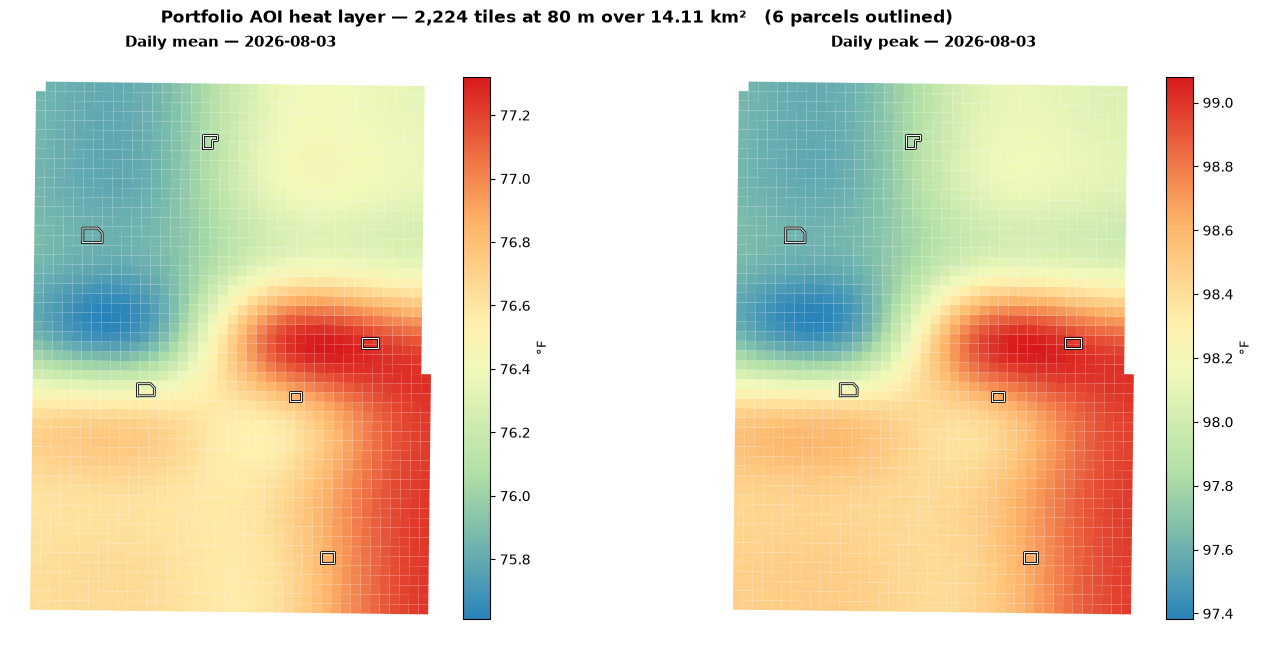

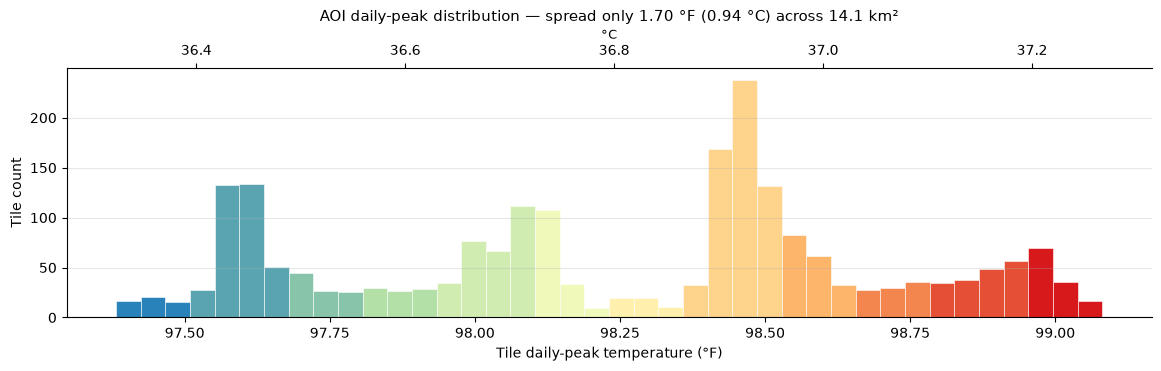

In [5]:
def draw_aoi_map(ax, values, title, cmap=TCM_CMAP, cbar_label='°F', to_f=True):
    """Tile choropleth of the AOI with every parcel boundary drawn on top."""
    vals = [v for v in values if v is not None]
    lo, hi = min(vals), max(vals)
    for (poly, *_), v in zip(tiles, values):
        if v is None:
            continue
        ax.fill(*poly.exterior.xy, color=cmap(0 if hi == lo else (v - lo) / (hi - lo)),
                linewidth=0)
    for p in PARCELS:
        ax.plot(*p['geom'].exterior.xy, color='#111', linewidth=2.0, zorder=5)
        ax.plot(*p['geom'].exterior.xy, color='#fff', linewidth=0.7, zorder=6)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_aspect(1 / math.cos(math.radians(CY)))
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    disp_lo, disp_hi = (c2f(lo), c2f(hi)) if to_f else (lo, hi)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=disp_lo, vmax=disp_hi))
    cb = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.02)
    cb.set_label(cbar_label, fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(14, 6.4), constrained_layout=True)
draw_aoi_map(axes[0], [t[1] for t in tiles], f'Daily mean — {STUDY_DATE}')
draw_aoi_map(axes[1], [t[2] for t in tiles], f'Daily peak — {STUDY_DATE}')
fig.suptitle(f'Portfolio AOI heat layer — {len(tiles):,} tiles at {GRANULARITY_M} m '
             f'over {AOI_KM2:.2f} km²   ({len(PARCELS)} parcels outlined)',
             fontsize=12.5, fontweight='bold')
fig_aoi = fig
plt.show()

fig, ax = plt.subplots(figsize=(11.5, 3.6), constrained_layout=True)
peaks_f = [c2f(v) for v in aoi_peaks]
lo, hi = min(aoi_peaks), max(aoi_peaks)
_, edges, patches = ax.hist(peaks_f, bins=40, edgecolor='white', linewidth=0.4)
for patch, e_lo, e_hi in zip(patches, edges[:-1], edges[1:]):
    patch.set_facecolor(temp_color(f2c((e_lo + e_hi) / 2), lo, hi))
ax.set_xlabel('Tile daily-peak temperature (°F)')
ax.set_ylabel('Tile count')
ax.set_title(f'AOI daily-peak distribution — spread only '
             f'{c2f(hi) - c2f(lo):.2f} °F ({hi - lo:.2f} °C) across {AOI_KM2:.1f} km²',
             fontsize=11)
ax.grid(axis='y', alpha=0.3)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
sec = ax.secondary_xaxis('top', functions=(f2c, c2f))
sec.set_xlabel('°C', fontsize=9)
plt.show()

## Step 3 — Clip the heat layer to each parcel and rank them

### What you are doing
For every parcel, an **area-weighted mean** of the tiles its boundary overlaps —
then a ranking.

### Why this matters
Each of these parcels is 1.8 to 4.6 acres and the tiles are 80 m, so a parcel
spans only a handful of tiles. A centroid lookup would assign the whole site the
value of whichever tile the centroid happened to land in, and on a 2-acre lot
that is close to arbitrary. Weighting every overlapping tile by how much of the
parcel it covers gives a number that does not move when the boundary is redrawn
slightly, which is what makes a *ranking* across six sites trustworthy.

In [6]:
for p in PARCELS:
    p['peak_c'], p['coverage'], p['n_tiles'] = clip_to_parcel(
        TILE_POLYS, [t[2] for t in tiles], p['geom'])
    p['mean_c'], _, _ = clip_to_parcel(TILE_POLYS, [t[1] for t in tiles], p['geom'])
    p['min_c'],  _, _ = clip_to_parcel(TILE_POLYS, [t[3] for t in tiles], p['geom'])
    p['swing_c'] = (None if None in (p['peak_c'], p['min_c'])
                    else p['peak_c'] - p['min_c'])
    srt = sorted(aoi_peaks)
    p['aoi_pct'] = 100.0 * sum(1 for v in srt if v < p['peak_c']) / len(srt)

PARCELS.sort(key=lambda p: -(p['peak_c'] if p['peak_c'] is not None else -999))
for i, p in enumerate(PARCELS, start=1):
    p['rank'] = i

aoi_median = float(np.median(aoi_peaks))
rows = []
for p in PARCELS:
    rows.append({
        'rank': p['rank'], 'parcel_id': p['parcel_id'], 'name': p['name'],
        'acres': round(p['area_acres'], 2),
        'daily peak': tf_short(p['peak_c']),
        'vs AOI median': f'{c2f(p["peak_c"]) - c2f(aoi_median):+.2f} °F '
                         f'({p["peak_c"] - aoi_median:+.2f} °C)',
        'AOI pct': f'{p["aoi_pct"]:.0f}th',
        'diurnal swing': tf_short(p['swing_c']),
        'tiles': p['n_tiles'],
    })
ranked_df = pd.DataFrame(rows)
display(ranked_df)

spread_f = c2f(PARCELS[0]['peak_c']) - c2f(PARCELS[-1]['peak_c'])
print(f'hottest to coolest parcel: {spread_f:.2f} °F '
      f'({PARCELS[0]["peak_c"] - PARCELS[-1]["peak_c"]:.2f} °C) — '
      f'{PARCELS[0]["name"]} vs {PARCELS[-1]["name"]}')
print(f'AOI-wide spread for reference: '
      f'{c2f(max(aoi_peaks)) - c2f(min(aoi_peaks)):.2f} °F '
      f'({max(aoi_peaks) - min(aoi_peaks):.2f} °C)')
print()
print('Every parcel covers 100% of its own boundary '
      f'({min(p["coverage"] for p in PARCELS) * 100:.0f}%+ tile coverage), so no '
      'parcel figure is extrapolated.')

,rank,parcel_id,name,acres,daily peak,vs AOI median,AOI pct,diurnal swing,tiles
0,1,APN-467-22-105,SJSU South Campus Edge,2.73,99.0°F (37.2°C),+0.59 °F (+0.33 °C),98th,68.9°F (20.5°C),6
1,2,APN-472-09-017,Spartan Keyes,2.33,98.7°F (37.0°C),+0.26 °F (+0.15 °C),83th,68.5°F (20.3°C),6
2,3,APN-264-11-032,SoFA District Infill,1.76,98.7°F (37.0°C),+0.26 °F (+0.14 °C),82th,68.5°F (20.3°C),3
3,4,APN-259-27-014,Diridon Gateway,3.33,98.2°F (36.8°C),-0.18 °F (-0.10 °C),46th,68.2°F (20.1°C),6
4,5,APN-249-40-008,Japantown Commons,2.65,97.8°F (36.6°C),-0.58 °F (-0.32 °C),23th,68.2°F (20.1°C),4
5,6,APN-259-33-041,Guadalupe River North,4.57,97.6°F (36.5°C),-0.79 °F (-0.44 °C),13th,68.0°F (20.0°C),6


hottest to coolest parcel: 1.38 °F (0.77 °C) — SJSU South Campus Edge vs Guadalupe River North
AOI-wide spread for reference: 1.70 °F (0.94 °C)

Every parcel covers 100% of its own boundary (100%+ tile coverage), so no parcel figure is extrapolated.


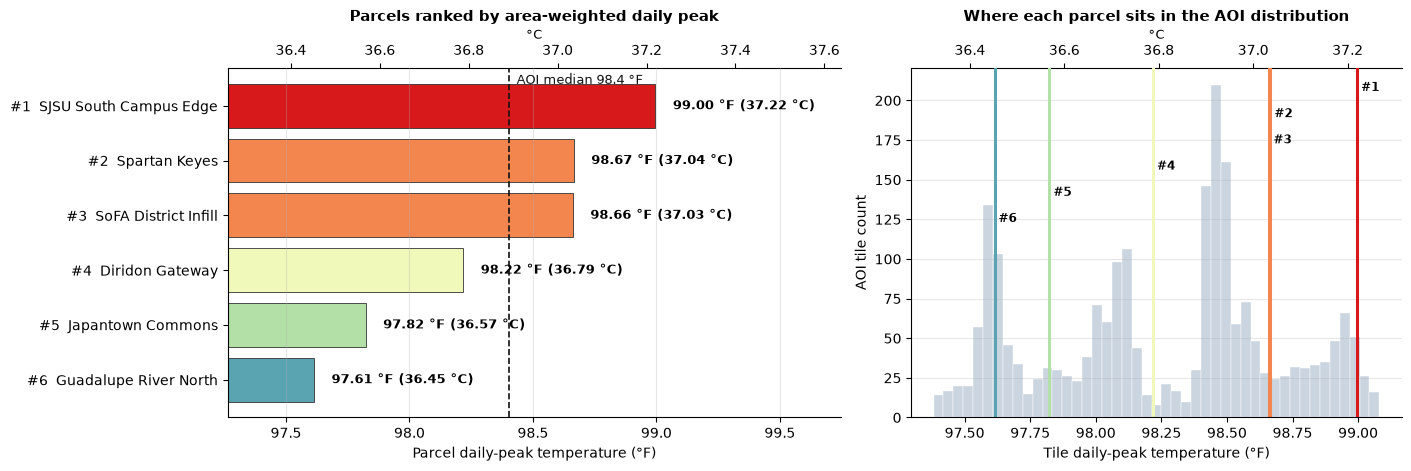

In [7]:
# Ranked comparison — parcels against each other and against the AOI distribution.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.6), constrained_layout=True,
                               gridspec_kw={'width_ratios': [1.25, 1]})

names   = [f'#{p["rank"]}  {p["name"]}' for p in PARCELS][::-1]
peaks_f = [c2f(p['peak_c']) for p in PARCELS][::-1]
lo, hi  = min(aoi_peaks), max(aoi_peaks)
cols    = [temp_color(p['peak_c'], lo, hi) for p in PARCELS][::-1]

axL.barh(names, peaks_f, color=cols, edgecolor='#333', linewidth=0.6)
axL.axvline(c2f(aoi_median), color='#111', ls='--', lw=1.2)
axL.text(c2f(aoi_median), len(names) - 0.4, f'  AOI median {c2f(aoi_median):.1f} °F',
         fontsize=9, va='top', color='#111')
for i, (p_f, p) in enumerate(zip(peaks_f, PARCELS[::-1])):
    axL.text(p_f + 0.03, i, f'  {p_f:.2f} °F ({p["peak_c"]:.2f} °C)',
             va='center', fontsize=9, fontweight='bold')
axL.set_xlim(min(peaks_f) - 0.35, max(peaks_f) + 0.75)
axL.set_xlabel('Parcel daily-peak temperature (°F)')
axL.set_title('Parcels ranked by area-weighted daily peak', fontsize=11, fontweight='bold')
axL.grid(axis='x', alpha=0.3)
for sp in ('top', 'right'):
    axL.spines[sp].set_visible(False)
sec = axL.secondary_xaxis('top', functions=(f2c, c2f))
sec.set_xlabel('°C', fontsize=9)

axR.hist([c2f(v) for v in aoi_peaks], bins=45, color='#cbd5e0', edgecolor='white',
         linewidth=0.3)
for p in PARCELS:
    axR.axvline(c2f(p['peak_c']), color=temp_color(p['peak_c'], lo, hi), lw=2.2)
    axR.text(c2f(p['peak_c']), axR.get_ylim()[1] * (0.96 - 0.075 * (p['rank'] - 1)),
             f' #{p["rank"]}', fontsize=8.5, fontweight='bold', va='top')
axR.set_xlabel('Tile daily-peak temperature (°F)')
axR.set_ylabel('AOI tile count')
axR.set_title('Where each parcel sits in the AOI distribution', fontsize=11,
              fontweight='bold')
axR.grid(axis='y', alpha=0.3)
for sp in ('top', 'right'):
    axR.spines[sp].set_visible(False)
sec = axR.secondary_xaxis('top', functions=(f2c, c2f))
sec.set_xlabel('°C', fontsize=9)

fig_rank = fig
plt.show()

## Step 4 — Exposure duration per parcel

### What you are doing
Two analysis heatmaps across the week ending on `STUDY_DATE`: **exceedance**
(hours above `EXCEEDANCE_C`) and **persistence** (longest unbroken run), each
clipped to every parcel.

### Why this matters
Step 3 ranked the parcels but the whole AOI spans under a degree Celsius, so the
gaps between them are small. Duration separates them far more sharply, and it is
also what the downstream decisions actually key off — annual cooling energy,
whether a slab sheds overnight heat, and whether a build window trips a heat
rule. If the two rankings disagree, that disagreement is the interesting finding.

In [8]:
def analytic_layer(kind, threshold, direction='above'):
    """Run (or load) one analysis heatmap and clip it to every parcel."""
    cache = HEATMAP_DIR / f'heatmap_{SLUG}_{WINDOW_START}_{WINDOW_END}_{kind}.json'
    res = cached_or_live(
        cache, f'heatmap {kind} {WINDOW_START}..{WINDOW_END}',
        client.create_heatmap if HAVE_API else None,
        polygon_aoi=AOI_FC, start_date=WINDOW_START, end_date=WINDOW_END,
        filter_type=4, granularity=GRANULARITY_M,
        analytic_type=kind, threshold=threshold, direction=direction,
    )
    feats = ((res.get('map_data') or {}).get('features', [])
             if isinstance(res.get('map_data'), dict) else [])
    polys = [shape(f['geometry']) for f in feats]
    vals  = [(f.get('properties') or {}).get('value') for f in feats]
    per_parcel = {}
    for p in PARCELS:
        v, _cov, _n = clip_to_parcel(polys, vals, p['geom'])
        per_parcel[p['parcel_id']] = v
    return {'kind': kind, 'polys': polys, 'values': vals, 'parcel': per_parcel,
            'stats': res.get('stats_data') or {}}


WINDOW_HOURS = ((pd.Timestamp(WINDOW_END) - pd.Timestamp(WINDOW_START)).days + 1) * 24

EXC = analytic_layer('exceedance',  EXCEEDANCE_C)
PER = analytic_layer('persistence', EXCEEDANCE_C)

for p in PARCELS:
    p['exceedance_h']  = EXC['parcel'].get(p['parcel_id'])
    p['persistence_h'] = PER['parcel'].get(p['parcel_id'])
    p['exceedance_share'] = (None if p['exceedance_h'] is None
                             else 100.0 * p['exceedance_h'] / WINDOW_HOURS)

exc_vals = [v for v in EXC['values'] if v is not None]
print()
print(f'Window {WINDOW_START} .. {WINDOW_END} = {WINDOW_HOURS} h,  '
      f'threshold {tf(EXCEEDANCE_C)}')
print(f'AOI exceedance range: {min(exc_vals):.1f} .. {max(exc_vals):.1f} h  '
      f'(spread {max(exc_vals) - min(exc_vals):.1f} h)')
print()
dur_rows = []
for p in sorted(PARCELS, key=lambda q: -(q['exceedance_h'] or 0)):
    dur_rows.append({
        'temp rank': p['rank'], 'parcel_id': p['parcel_id'], 'name': p['name'],
        'hours above thr': f'{p["exceedance_h"]:.1f}',
        '% of window': f'{p["exceedance_share"]:.0f}%',
        'longest run (h)': f'{p["persistence_h"]:.1f}',
        'daily peak': tf_short(p['peak_c']),
    })
duration_df = pd.DataFrame(dur_rows)
display(duration_df)

by_temp = [p['parcel_id'] for p in PARCELS]
by_dur  = [p['parcel_id'] for p in sorted(PARCELS, key=lambda q: -(q['exceedance_h'] or 0))]
print(f'ranking by peak temperature : {" > ".join(by_temp)}')
print(f'ranking by exposure duration: {" > ".join(by_dur)}')
print('  -> ' + ('same order — the two metrics agree here.' if by_temp == by_dur else
                 'THE ORDERS DIFFER. Duration is the metric the mechanical and '
                 'scheduling decisions key off, so it should lead the shortlist.'))

cached: heatmap exceedance 2026-07-28..2026-08-03 <- data/heatmaps/heatmap_parcel_portfolio_san_jose_2026-07-28_2026-08-03_exceedance.json
cached: heatmap persistence 2026-07-28..2026-08-03 <- data/heatmaps/heatmap_parcel_portfolio_san_jose_2026-07-28_2026-08-03_persistence.json



Window 2026-07-28 .. 2026-08-03 = 168 h,  threshold 89.6 °F (32.0 °C)
AOI exceedance range: 13.1 .. 19.6 h  (spread 6.5 h)



,temp rank,parcel_id,name,hours above thr,% of window,longest run (h),daily peak
0,1,APN-467-22-105,SJSU South Campus Edge,19.3,11%,5.0,99.0°F (37.2°C)
1,2,APN-472-09-017,Spartan Keyes,17.9,11%,5.0,98.7°F (37.0°C)
2,3,APN-264-11-032,SoFA District Infill,17.8,11%,5.0,98.7°F (37.0°C)
3,4,APN-259-27-014,Diridon Gateway,16.1,10%,4.7,98.2°F (36.8°C)
4,5,APN-249-40-008,Japantown Commons,14.9,9%,4.4,97.8°F (36.6°C)
5,6,APN-259-33-041,Guadalupe River North,13.9,8%,3.9,97.6°F (36.5°C)


ranking by peak temperature : APN-467-22-105 > APN-472-09-017 > APN-264-11-032 > APN-259-27-014 > APN-249-40-008 > APN-259-33-041
ranking by exposure duration: APN-467-22-105 > APN-472-09-017 > APN-264-11-032 > APN-259-27-014 > APN-249-40-008 > APN-259-33-041
  -> same order — the two metrics agree here.


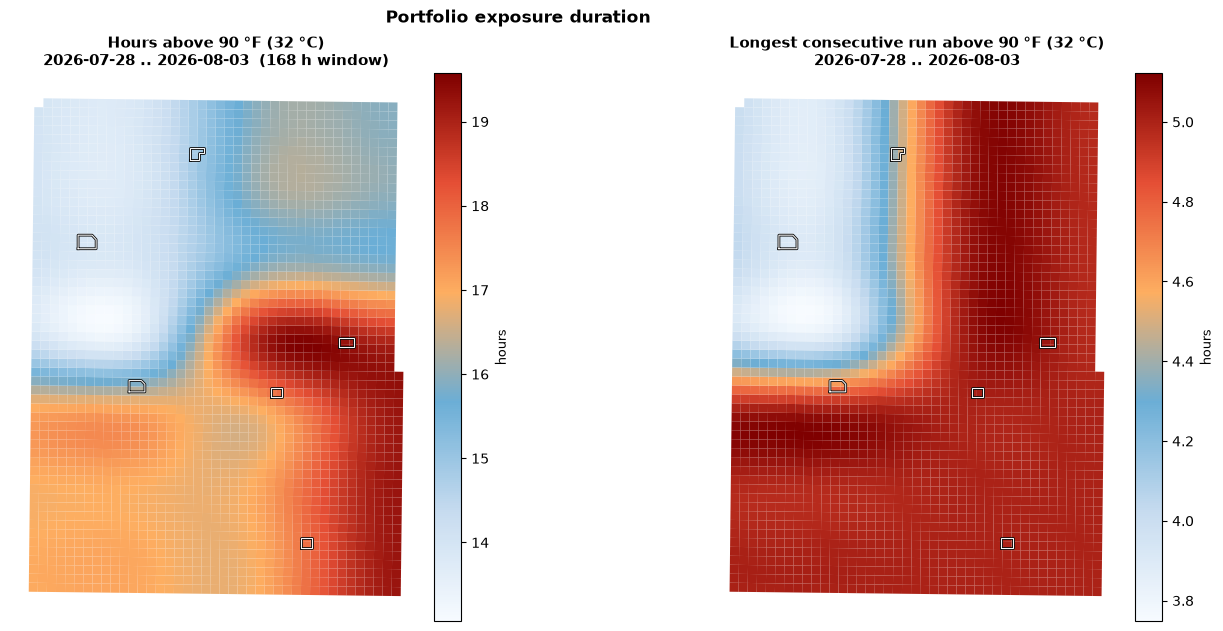

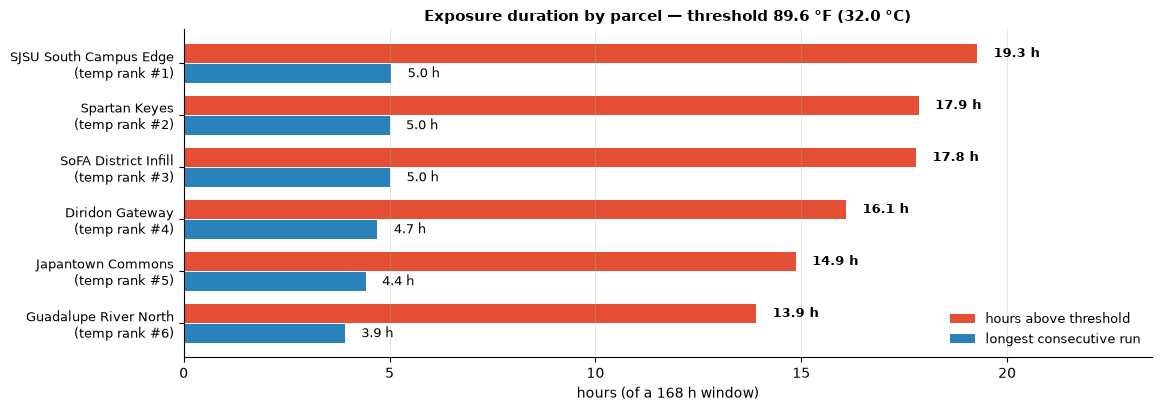

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.2), constrained_layout=True)
for ax, layer, title in (
    (axes[0], EXC, f'Hours above {c2f(EXCEEDANCE_C):.0f} °F ({EXCEEDANCE_C:g} °C)\n'
                   f'{WINDOW_START} .. {WINDOW_END}  ({WINDOW_HOURS} h window)'),
    (axes[1], PER, f'Longest consecutive run above {c2f(EXCEEDANCE_C):.0f} °F '
                   f'({EXCEEDANCE_C:g} °C)\n{WINDOW_START} .. {WINDOW_END}'),
):
    vals = [v for v in layer['values'] if v is not None]
    lo, hi = min(vals), max(vals)
    for poly, v in zip(layer['polys'], layer['values']):
        if v is None:
            continue
        ax.fill(*poly.exterior.xy,
                color=HOURS_CMAP(0 if hi == lo else (v - lo) / (hi - lo)), linewidth=0)
    for p in PARCELS:
        ax.plot(*p['geom'].exterior.xy, color='#111', linewidth=2.0, zorder=5)
        ax.plot(*p['geom'].exterior.xy, color='#fff', linewidth=0.7, zorder=6)
    ax.set_title(title, fontsize=10.5, fontweight='bold')
    ax.set_aspect(1 / math.cos(math.radians(CY)))
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    sm = plt.cm.ScalarMappable(cmap=HOURS_CMAP, norm=plt.Normalize(vmin=lo, vmax=hi))
    cb = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.02)
    cb.set_label('hours', fontsize=9)

fig.suptitle('Portfolio exposure duration', fontsize=12.5, fontweight='bold')
fig_duration = fig
plt.show()

# Side-by-side: does the duration ranking match the temperature ranking?
fig, ax = plt.subplots(figsize=(11.5, 4.0), constrained_layout=True)
order = sorted(PARCELS, key=lambda q: -(q['exceedance_h'] or 0))
lbl   = [f'{p["name"]}\n(temp rank #{p["rank"]})' for p in order][::-1]
hrs   = [p['exceedance_h'] for p in order][::-1]
runs  = [p['persistence_h'] for p in order][::-1]
ypos  = np.arange(len(lbl))
ax.barh(ypos + 0.19, hrs,  height=0.36, color='#e54f35', label='hours above threshold')
ax.barh(ypos - 0.19, runs, height=0.36, color='#2983ba', label='longest consecutive run')
for y, (h, r) in enumerate(zip(hrs, runs)):
    ax.text(h + 0.4, y + 0.19, f'{h:.1f} h', va='center', fontsize=9, fontweight='bold')
    ax.text(r + 0.4, y - 0.19, f'{r:.1f} h', va='center', fontsize=9)
ax.set_yticks(ypos); ax.set_yticklabels(lbl, fontsize=9)
ax.set_xlabel(f'hours (of a {WINDOW_HOURS} h window)')
ax.set_title(f'Exposure duration by parcel — threshold {tf(EXCEEDANCE_C)}',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='lower right', frameon=False)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(hrs) * 1.22)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
fig_duration_bars = fig
plt.show()

## Step 5 — Why the top parcels are hot: satellite segmentation

### What you are doing
Satellite land-cover segmentation on the top `TOP_N` parcels, presented the way
the bus-stop notebook does it: the original tile and the segmentation overlay side
by side, then a stacked composition bar and per-class bars tagged
**heating / cooling / sky**.

### Why this matters
The heat layers rank the sites; this explains them, and the explanation is what
survives into an investment memo. The heating/cooling split is the actionable
read — a parcel that is 80% heating surfaces has an obvious remedy in the
landscape and paving spec, while one that is already well vegetated and still
hot is telling you the problem is district-scale and will not be fixed on site.

cached: satellite #1 APN-467-22-105 <- data/satellite/satellite_parcel_portfolio_san_jose_APN-467-22-105_2026-08-03.json


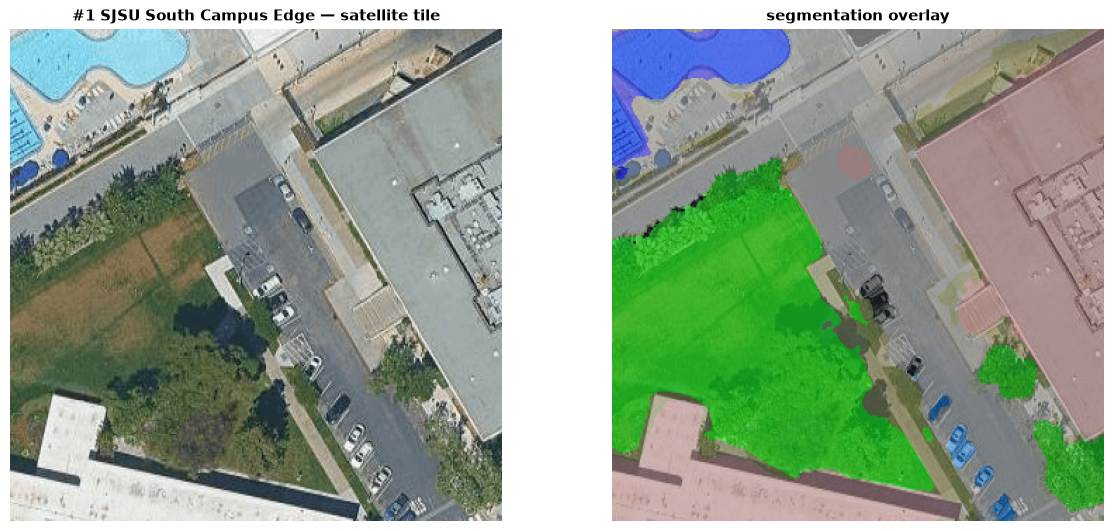

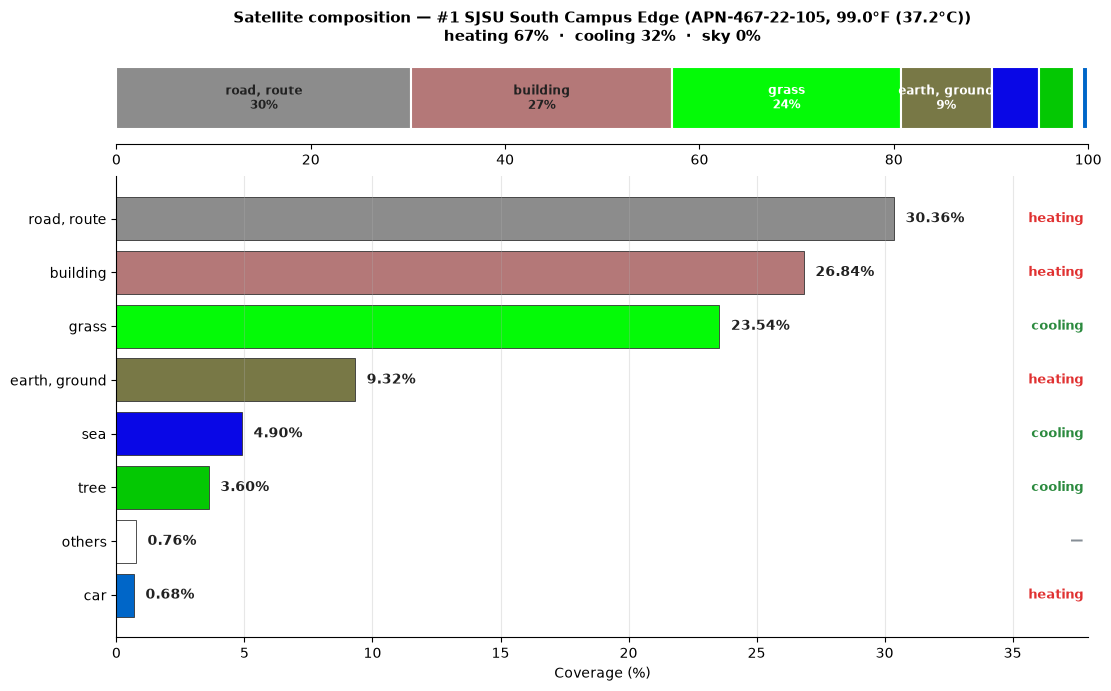

cached: satellite #2 APN-472-09-017 <- data/satellite/satellite_parcel_portfolio_san_jose_APN-472-09-017_2026-08-03.json


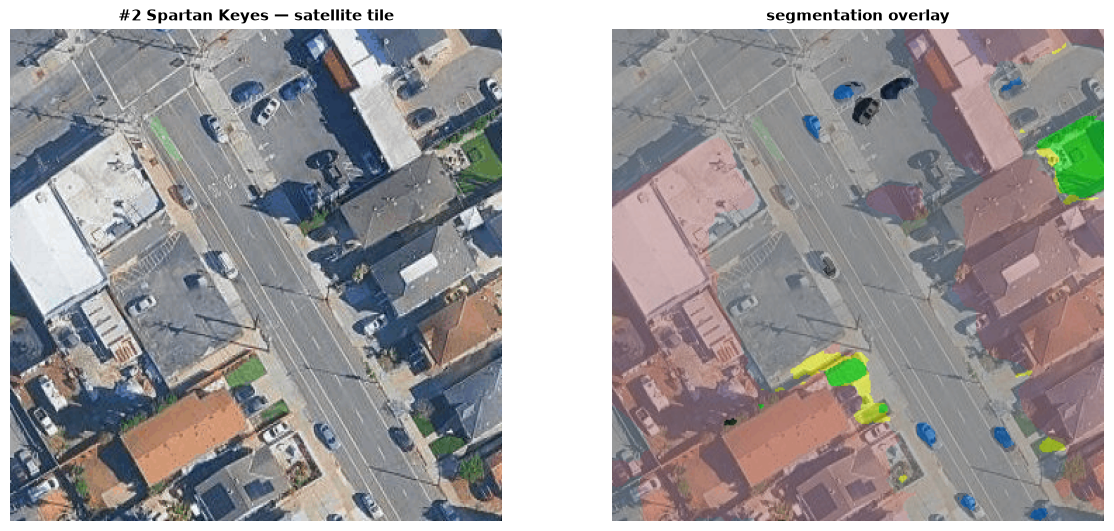

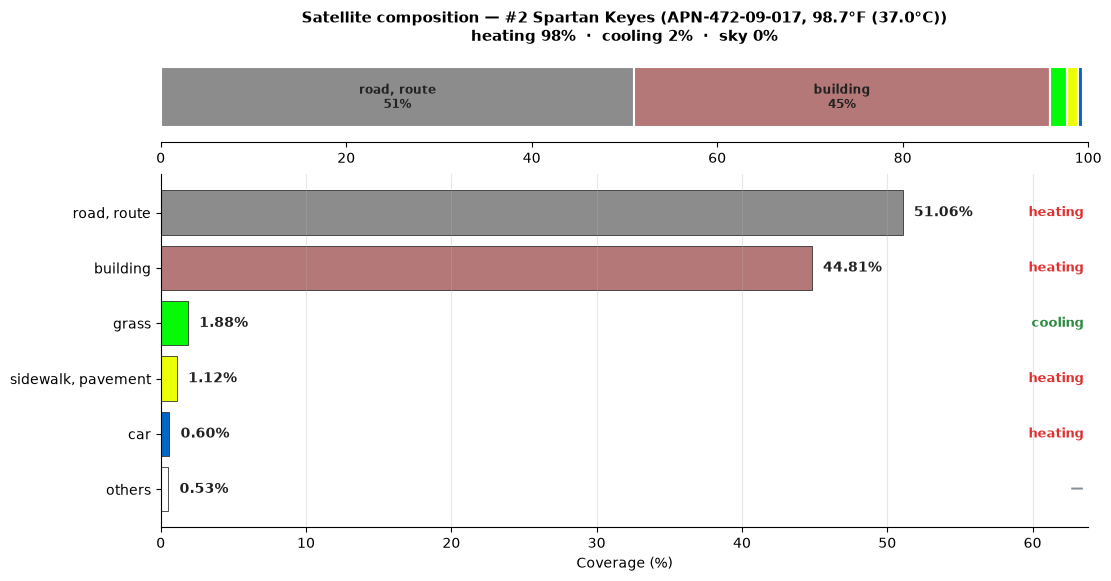

cached: satellite #3 APN-264-11-032 <- data/satellite/satellite_parcel_portfolio_san_jose_APN-264-11-032_2026-08-03.json


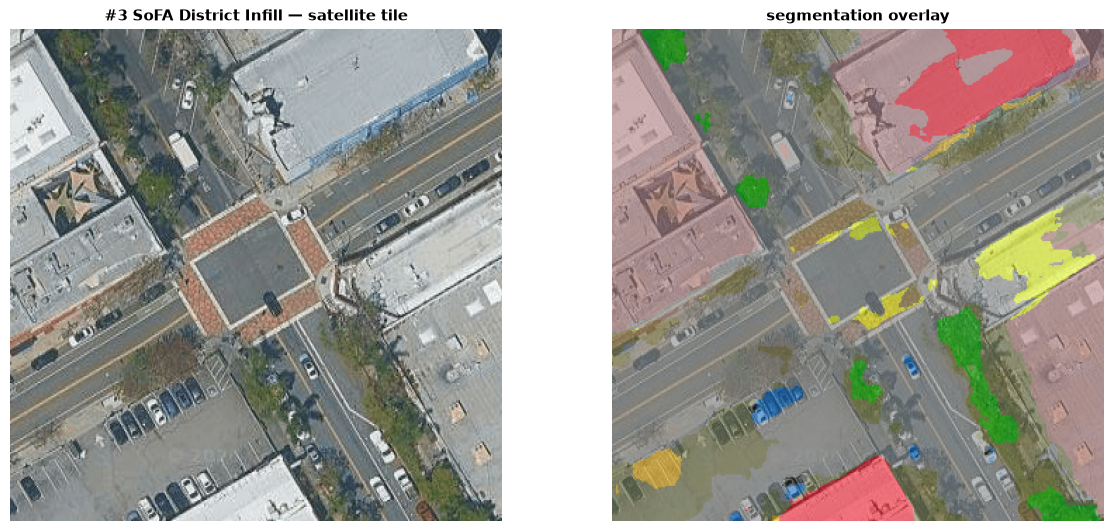

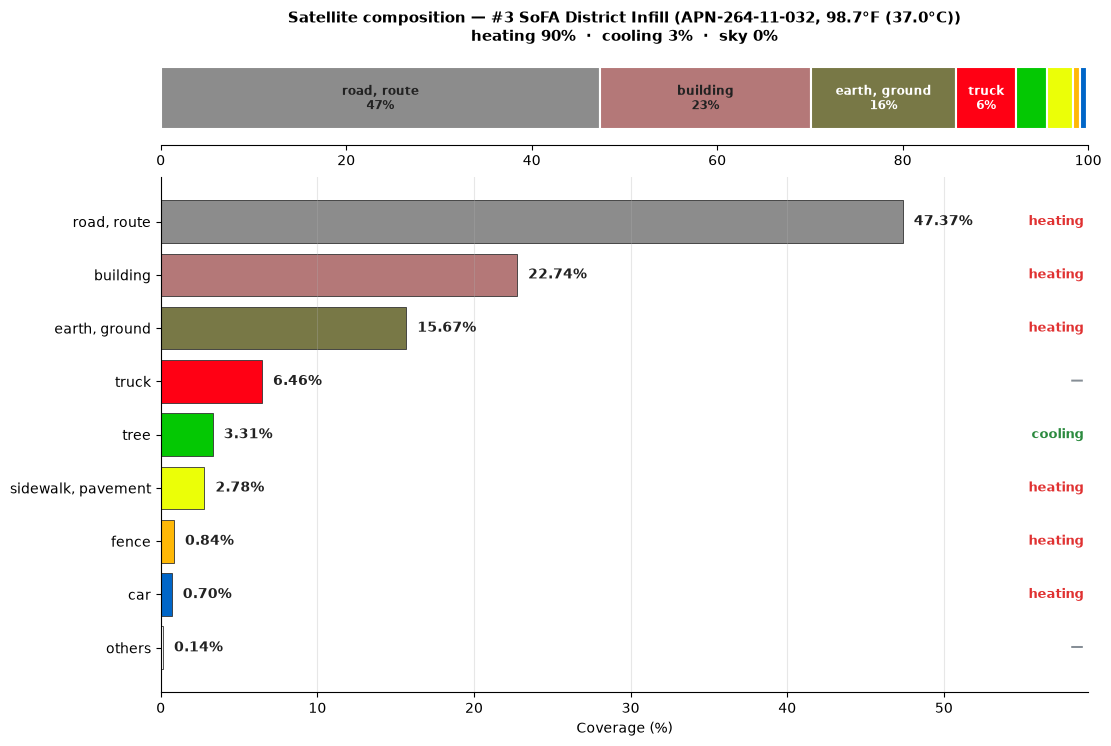

,rank,parcel_id,name,daily peak,heating %,cooling %,canopy %
0,1,APN-467-22-105,SJSU South Campus Edge,99.0°F (37.2°C),67.2,32.0,3.6
1,2,APN-472-09-017,Spartan Keyes,98.7°F (37.0°C),97.6,1.9,0.0
2,3,APN-264-11-032,SoFA District Infill,98.7°F (37.0°C),90.1,3.3,3.3


In [10]:
SAT_RESULTS = {}

for p in PARCELS[:TOP_N]:
    res = cached_or_live(
        SAT_SEG_DIR / f'satellite_{SLUG}_{p["parcel_id"]}_{STUDY_DATE}.json',
        f'satellite #{p["rank"]} {p["parcel_id"]}',
        client.satellite_segmentation if HAVE_API else None,
        latitude=p['lat'], longitude=p['lon'],
        start_date=STUDY_DATE, start_time=STUDY_HOUR,
        filter_type=3, granularity=GRANULARITY_M, skip_on_failure=True,
    )
    if not res:
        continue
    SAT_RESULTS[p['parcel_id']] = res
    seg     = res.get('segmentation') or {}
    segs    = {k: float(v) for k, v in (seg.get('segments') or {}).items()}
    legend  = seg.get('image_legend') or {}
    p['sat_segments'] = segs
    p['sat_legend']   = legend

    cats = {c: sum(v for k, v in segs.items() if _seg_category(k) == c)
            for c in ('heating', 'cooling', 'sky', '—')}
    p['impervious_pct'] = cats['heating']
    p['canopy_pct']     = sum(v for k, v in segs.items() if 'tree' in k.lower())
    p['vegetation_pct'] = cats['cooling']

    original  = decode_b64(res.get('original_image') or res.get('orignal_image'))
    segmented = decode_b64(seg.get('image_content'))
    imgs = [(f'#{p["rank"]} {p["name"]} — satellite tile', original),
            ('segmentation overlay', segmented)]
    imgs = [(t, im) for t, im in imgs if im is not None]
    if imgs:
        fig, axs = plt.subplots(1, len(imgs), figsize=(6.0 * len(imgs), 5.2),
                                constrained_layout=True)
        axs = np.atleast_1d(axs)
        for ax, (t, im) in zip(axs, imgs):
            ax.imshow(im); ax.axis('off')
            ax.set_title(t, fontsize=10.5, fontweight='bold')
        plt.show()

    show_segmentation_breakdown(
        segs, legend,
        title=f'Satellite composition — #{p["rank"]} {p["name"]} '
              f'({p["parcel_id"]}, {tf_short(p["peak_c"])})')

sat_rows = [{
    'rank': p['rank'], 'parcel_id': p['parcel_id'], 'name': p['name'],
    'daily peak': tf_short(p['peak_c']),
    'heating %': f'{p.get("impervious_pct", float("nan")):.1f}',
    'cooling %': f'{p.get("vegetation_pct", float("nan")):.1f}',
    'canopy %':  f'{p.get("canopy_pct", float("nan")):.1f}',
} for p in PARCELS[:TOP_N] if 'sat_segments' in p]
if sat_rows:
    display(pd.DataFrame(sat_rows))

## Step 6 — Ground truth: street-view segmentation

### What you are doing
Street-view segmentation at each top parcel's frontage, with the same
original-plus-overlay treatment and the same heating/cooling/sky breakdown.

### Why this matters
Satellite sees the roof plane; a tenant, a customer, and a construction crew all
experience the vertical environment. A parcel can look adequately planted from
above and still present a fully paved, unshaded frontage at eye level — which is
the difference between a ground-floor retail pro-forma that works and one that
does not. Imagery is not available everywhere, so these calls use
`skip_on_failure=True` and the notebook continues without them.

cached: street-view #1 APN-467-22-105 <- data/street_view/streetview_parcel_portfolio_san_jose_APN-467-22-105.json


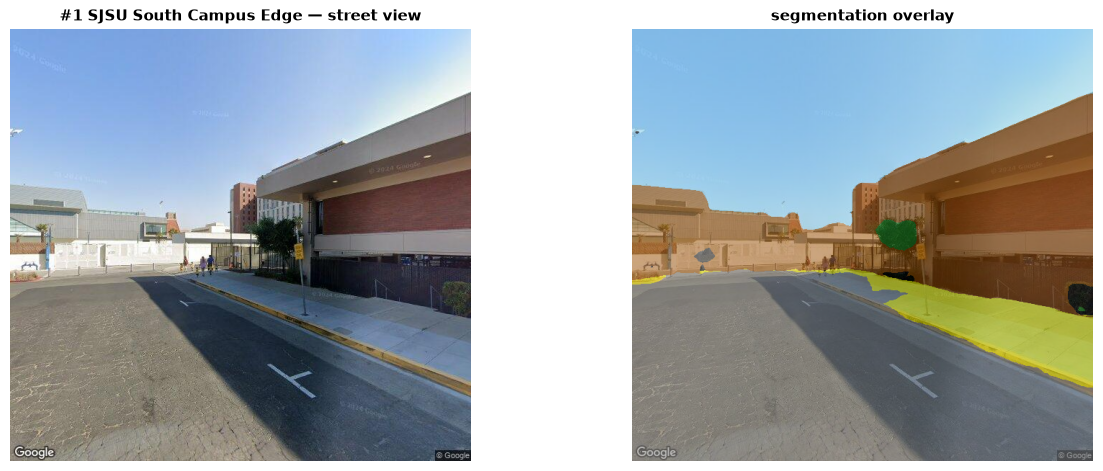

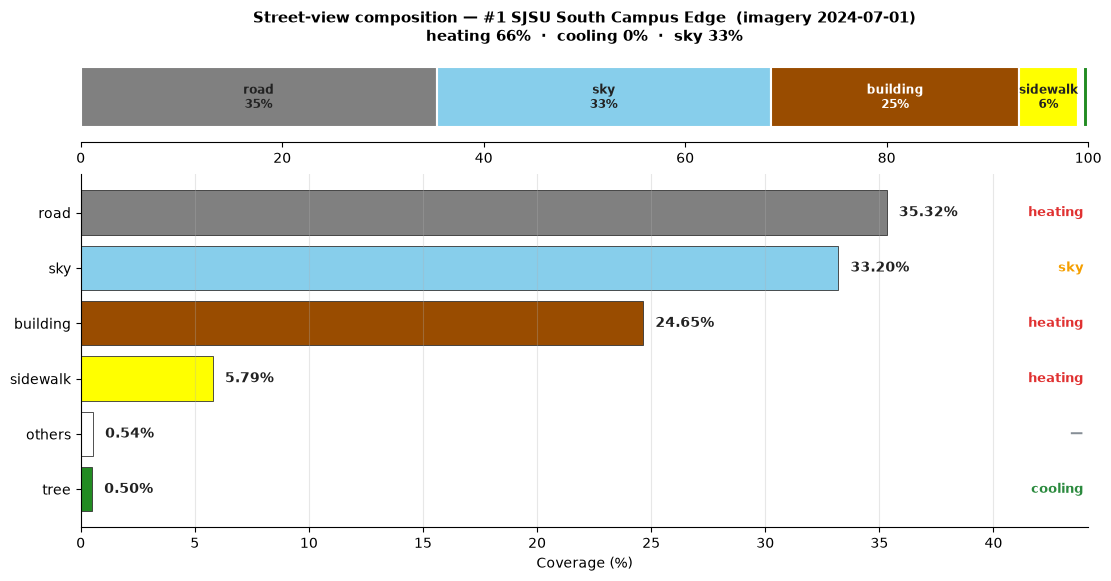

cached: street-view #2 APN-472-09-017 <- data/street_view/streetview_parcel_portfolio_san_jose_APN-472-09-017.json


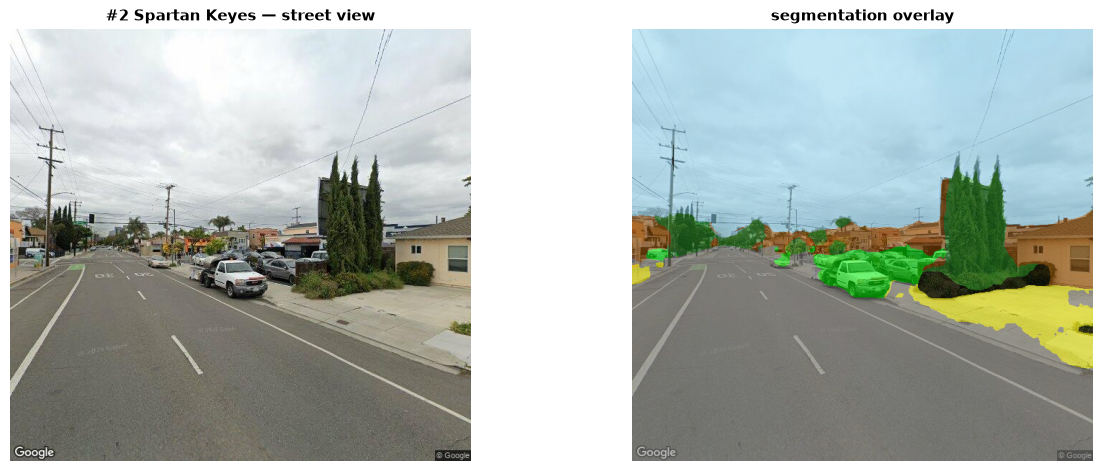

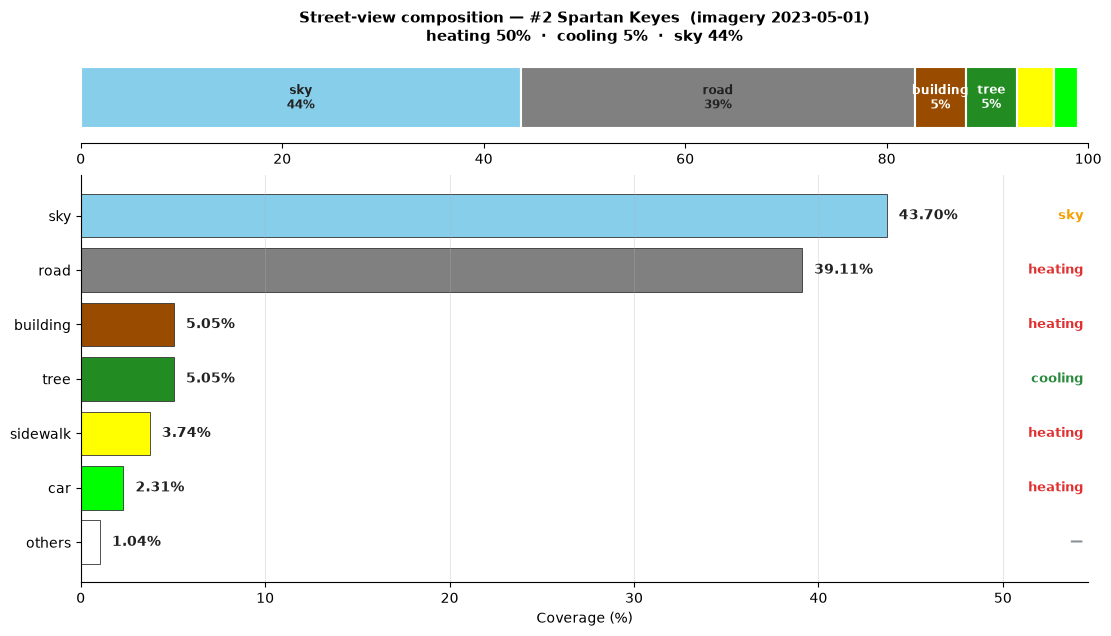

cached: street-view #3 APN-264-11-032 <- data/street_view/streetview_parcel_portfolio_san_jose_APN-264-11-032.json


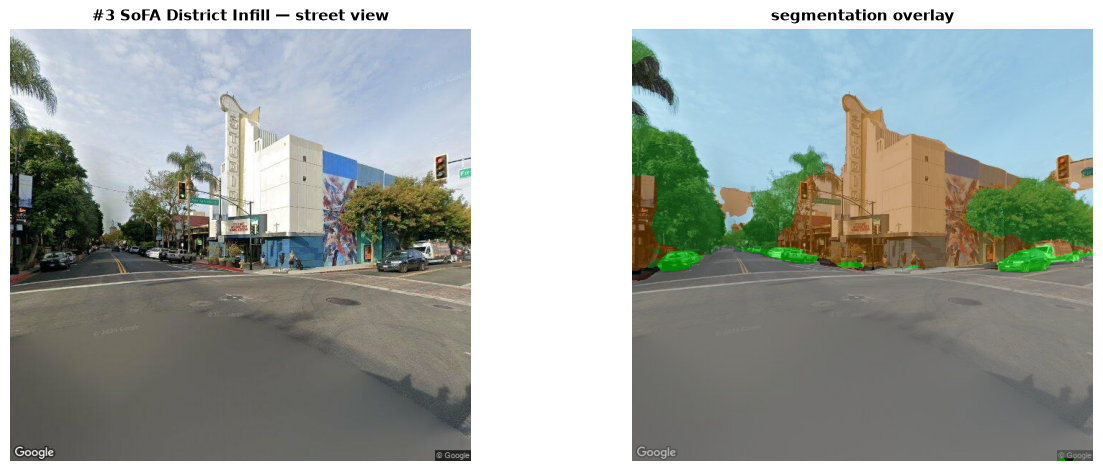

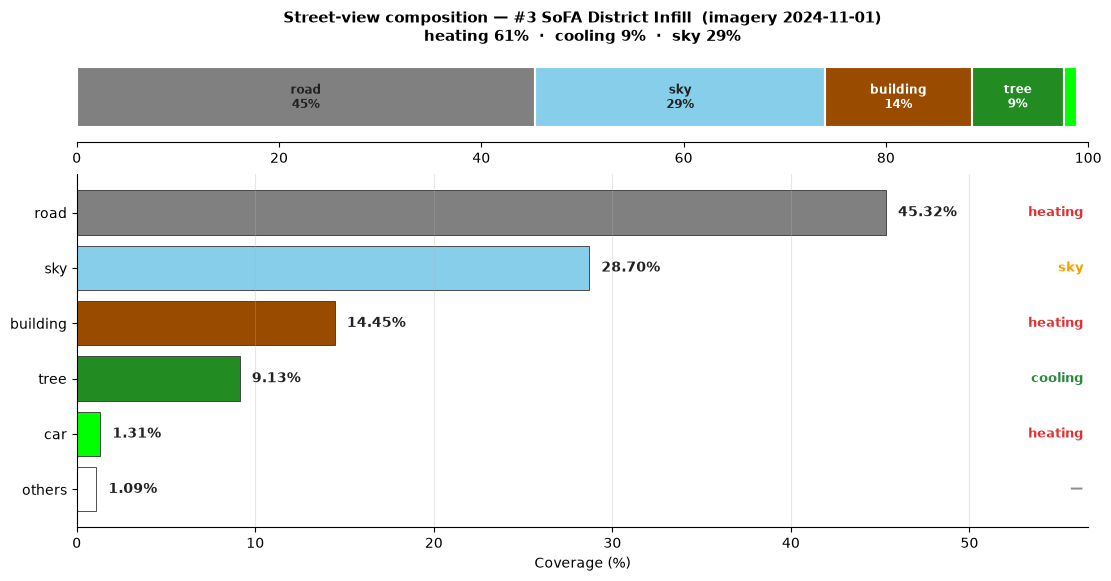

,rank,parcel_id,name,imagery,hard surface %,vegetation %,visible sky %
0,1,APN-467-22-105,SJSU South Campus Edge,2024-07-01,65.8,0.5,33.2
1,2,APN-472-09-017,Spartan Keyes,2023-05-01,50.2,5.0,43.7
2,3,APN-264-11-032,SoFA District Infill,2024-11-01,61.1,9.1,28.7


In [11]:
SV_RESULTS = {}

for p in PARCELS[:TOP_N]:
    res = cached_or_live(
        STREET_SEG_DIR / f'streetview_{SLUG}_{p["parcel_id"]}.json',
        f'street-view #{p["rank"]} {p["parcel_id"]}',
        client.street_view_segmentation if HAVE_API else None,
        latitude=p['lat'], longitude=p['lon'], skip_on_failure=True, timeout=300,
    )
    if not res:
        continue
    SV_RESULTS[p['parcel_id']] = res
    front  = res.get('front') or {}
    segs   = {k: float(v) for k, v in (front.get('segments') or {}).items()}
    legend = front.get('image_legend') or {}
    p['sv_segments'] = segs
    p['sv_date']     = front.get('image_date')
    p['sv_veg']      = sum(v for k, v in segs.items() if _seg_category(k) == 'cooling')
    p['sv_sky']      = sum(v for k, v in segs.items() if _seg_category(k) == 'sky')
    p['sv_hard']     = sum(v for k, v in segs.items() if _seg_category(k) == 'heating')

    imgs = [(f'#{p["rank"]} {p["name"]} — street view', decode_b64(front.get('original_image'))),
            ('segmentation overlay', decode_b64(front.get('segmented_image')))]
    imgs = [(t, im) for t, im in imgs if im is not None]
    if imgs:
        fig, axs = plt.subplots(1, len(imgs), figsize=(6.2 * len(imgs), 4.6),
                                constrained_layout=True)
        axs = np.atleast_1d(axs)
        for ax, (t, im) in zip(axs, imgs):
            ax.imshow(im); ax.axis('off')
            ax.set_title(t, fontsize=10.5, fontweight='bold')
        plt.show()

    show_segmentation_breakdown(
        segs, legend,
        title=f'Street-view composition — #{p["rank"]} {p["name"]}'
              + (f'  (imagery {p["sv_date"]})' if p.get('sv_date') else ''))

sv_rows = [{
    'rank': p['rank'], 'parcel_id': p['parcel_id'], 'name': p['name'],
    'imagery': p.get('sv_date') or '—',
    'hard surface %': f'{p.get("sv_hard", float("nan")):.1f}',
    'vegetation %':   f'{p.get("sv_veg", float("nan")):.1f}',
    'visible sky %':  f'{p.get("sv_sky", float("nan")):.1f}',
} for p in PARCELS[:TOP_N] if 'sv_segments' in p]
if sv_rows:
    display(pd.DataFrame(sv_rows))
else:
    print('No street-view imagery available for any top parcel.')

## Step 7 — Comfort through the day

### What you are doing
Environmental parameters at each top parcel, anchored to that parcel's
area-weighted peak from Step 3, laid out as **five separate panels** — diurnal
curves, a NOAA heat-stress gauge, humidity, a thermal breakdown at the hot hour,
and air quality — rather than stacked on one crowded axis.

### Why this matters, and one trap to know about

The endpoint applies your single `temperature` anchor to **all 24 hours** and
varies only humidity. Heat index is a function of both, so the returned
`heat_index_celsius` series tracks relative humidity — and since humidity peaks
overnight, **the heat-index curve peaks at around 2 a.m. and bottoms out in the
afternoon.** It is a humidity-sensitivity curve at a fixed temperature, not a
diurnal forecast, and it is only physically meaningful where the real air
temperature is near the anchor: the afternoon peak.

So every threshold comparison below is taken at the **hot hour** — the hour when
`apparent_temperature_celsius`, which *does* follow the real diurnal cycle, is
highest. All *duration* figures come from the measured `exceedance` layer in
Step 4, never from counting hours in this series.

The chart axis is scaled to the physically meaningful series, so on a hot day
the overnight heat-index artifact clips off the top with a note saying where it
went — rather than compressing every real curve into the bottom of the panel.
The raw series maximum is kept in `parcel_screening.csv`
(`heat_index_series_max_c`) for traceability, but it drives no finding.

### And a second limit: this endpoint is coarser than your parcels

`env_params` resolves on a weather grid that is coarser than parcels within one
district are apart. In the bundled run, two parcels **1.36 km apart return
byte-identical parameter arrays** — same apparent temperature, same wet-bulb,
same humidity, same air quality — because they land in the same grid cell.

That means the only column that varies between those parcels is heat index, and
it varies *solely* because each parcel supplies its own `temperature` anchor
from Step 3. It is a re-expression of the heatmap, not an independent
measurement at that location. The cell below detects this and says so
explicitly.

Practical consequence: use these curves to characterise **the district** the
portfolio sits in, not to discriminate between parcels inside it. Ranking
between parcels comes from the heatmap layers in Steps 3 and 4, which resolve at
`GRANULARITY_M` and genuinely do vary per site.

cached: env-params #1 APN-467-22-105 <- data/env_params/env_params_parcel_portfolio_san_jose_APN-467-22-105_2026-08-03.json


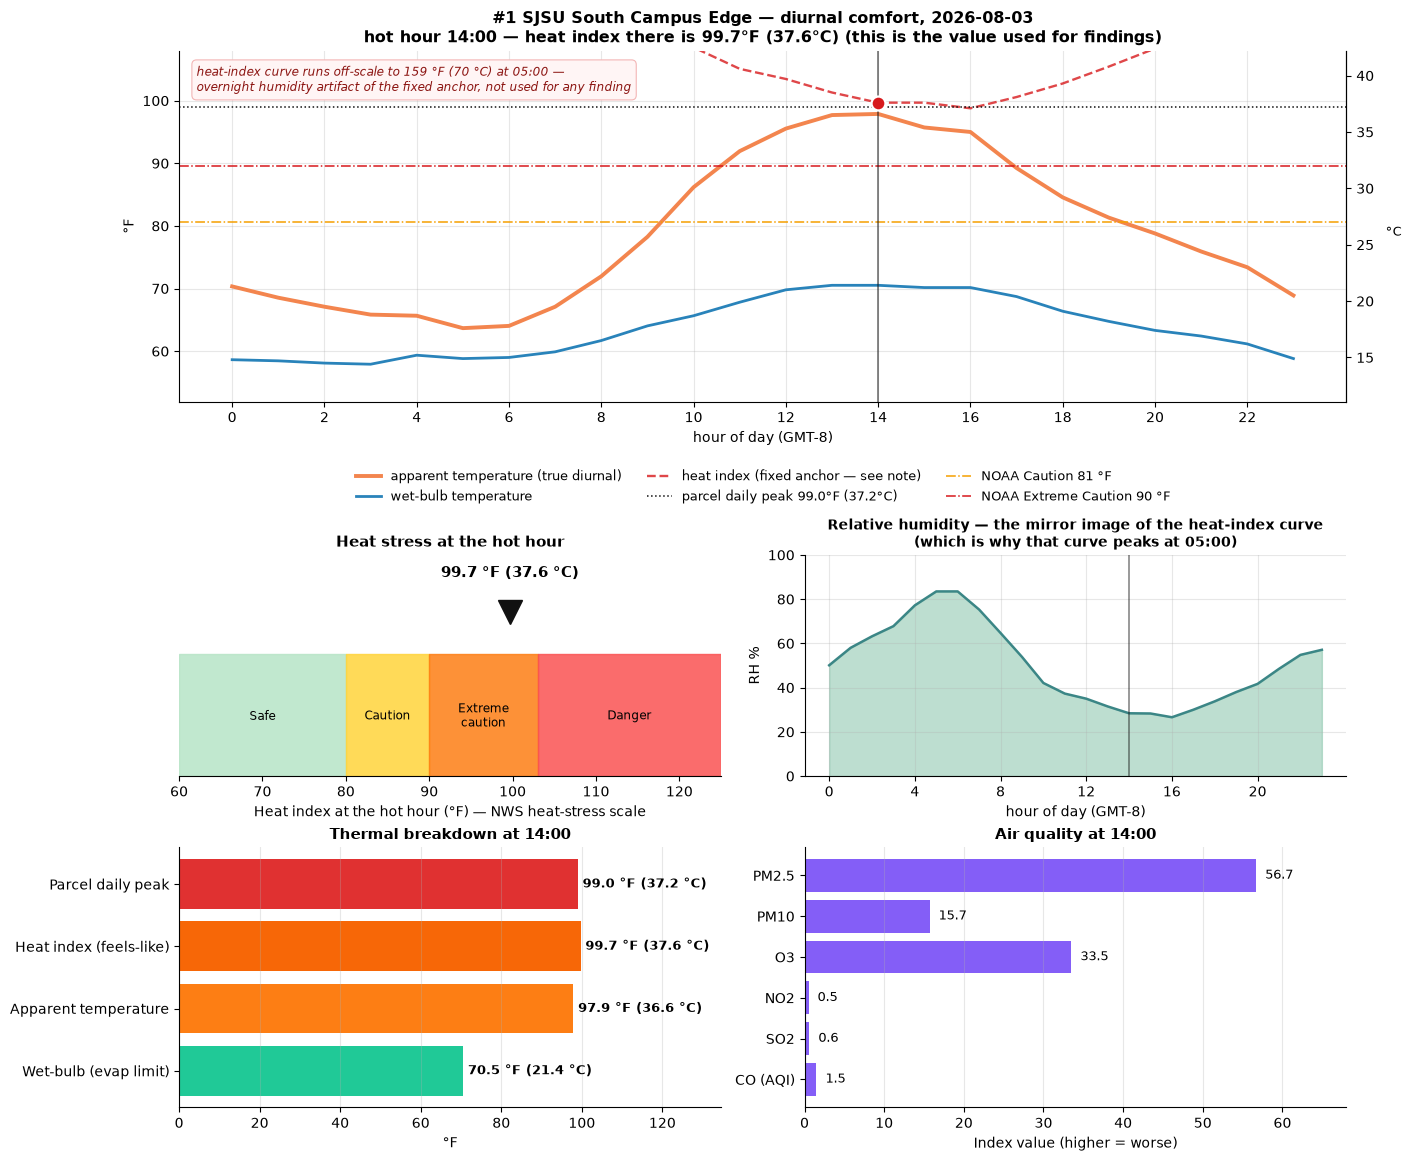

cached: env-params #2 APN-472-09-017 <- data/env_params/env_params_parcel_portfolio_san_jose_APN-472-09-017_2026-08-03.json


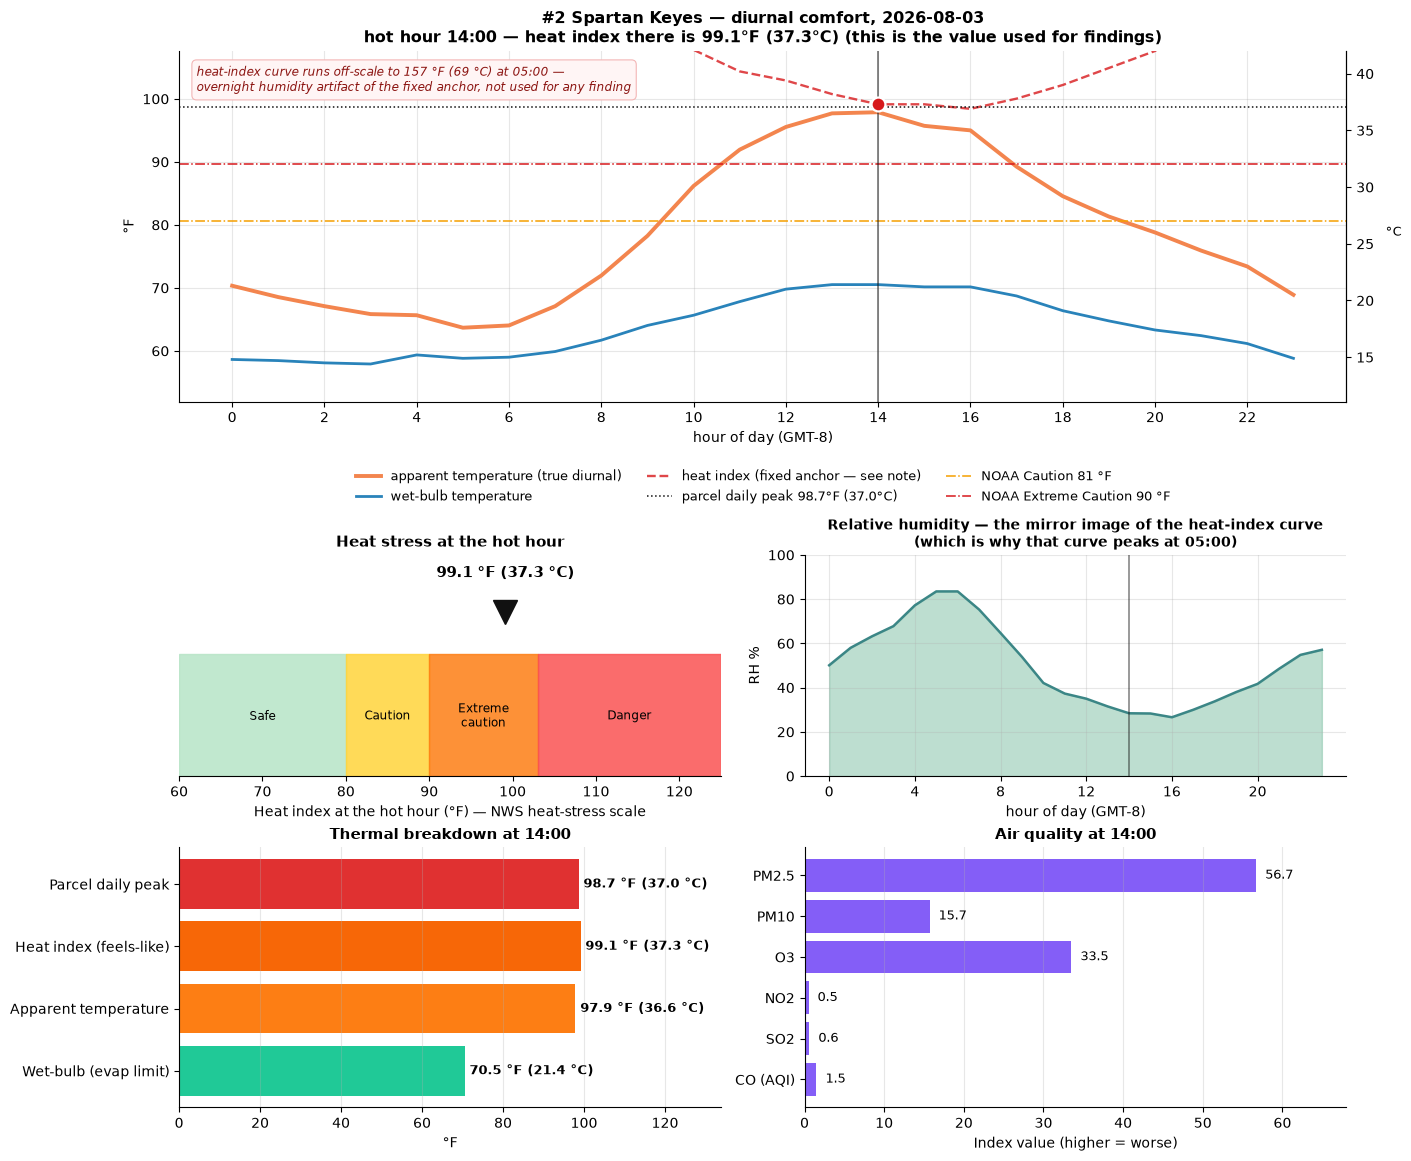

cached: env-params #3 APN-264-11-032 <- data/env_params/env_params_parcel_portfolio_san_jose_APN-264-11-032_2026-08-03.json


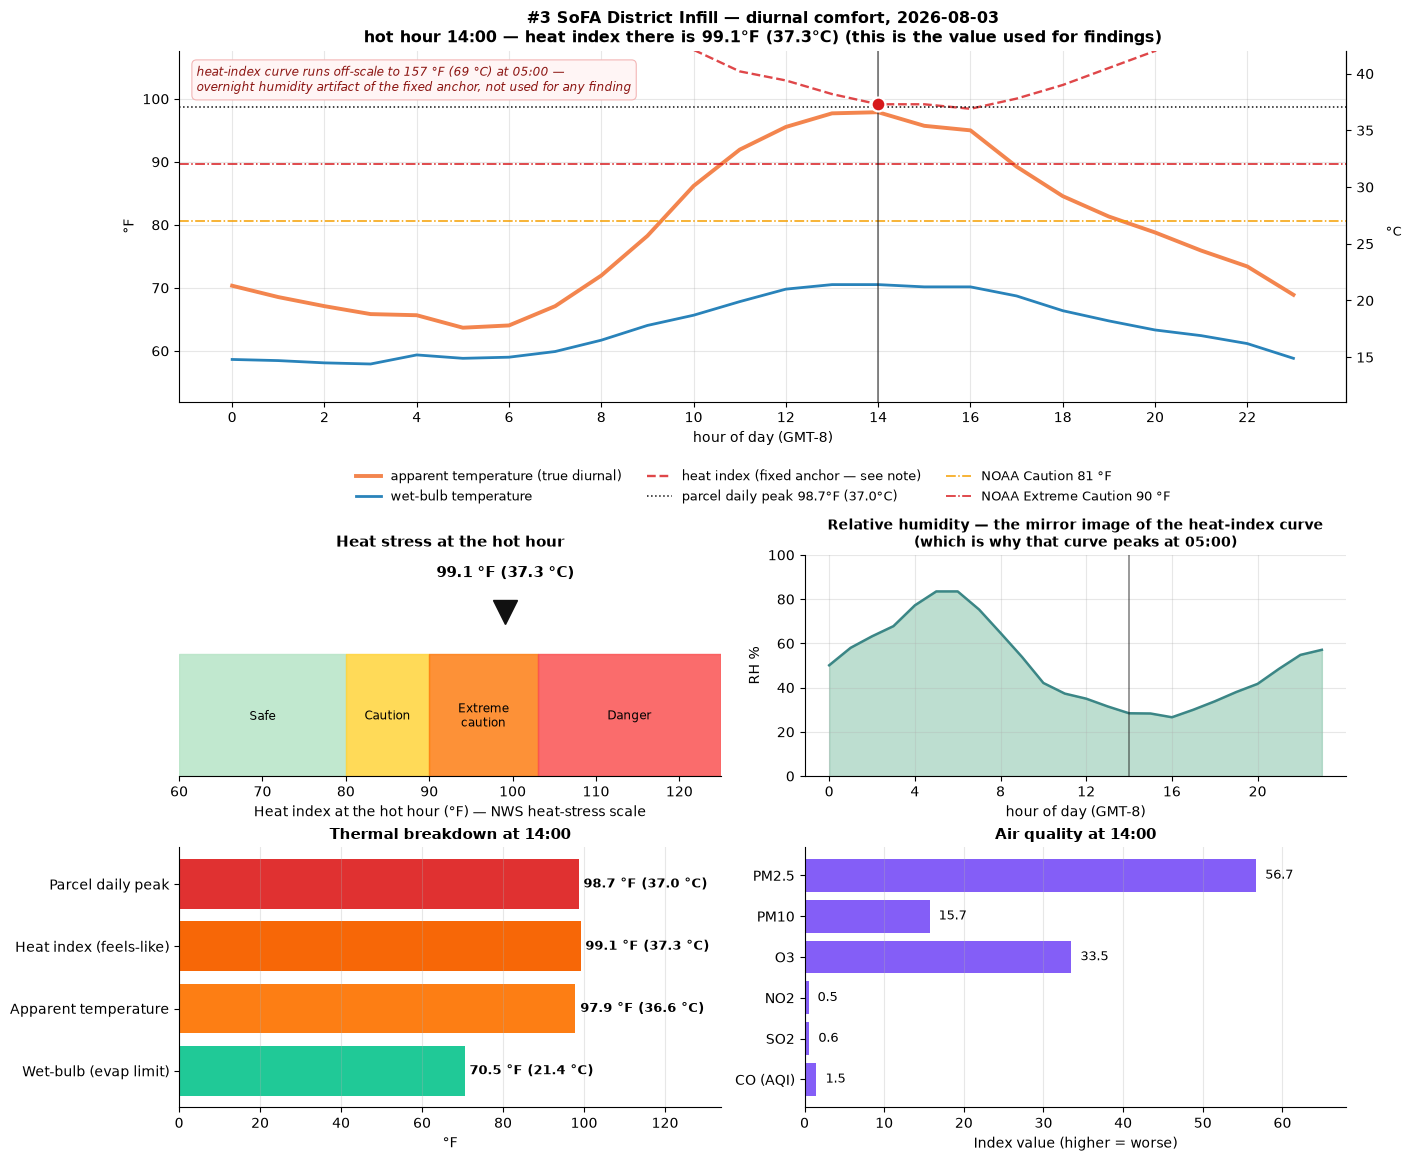

,rank,parcel_id,name,hot hour,heat index @ hot hour,apparent peak,wet-bulb @ hot hour
0,1,APN-467-22-105,SJSU South Campus Edge,14:00,99.7°F (37.6°C),97.9°F (36.6°C),70.5°F (21.4°C)
1,2,APN-472-09-017,Spartan Keyes,14:00,99.1°F (37.3°C),97.9°F (36.6°C),70.5°F (21.4°C)
2,3,APN-264-11-032,SoFA District Infill,14:00,99.1°F (37.3°C),97.9°F (36.6°C),70.5°F (21.4°C)



NOTE — env_params grid resolution:
  identical parameter series returned for: APN-472-09-017 (Spartan Keyes), APN-264-11-032 (SoFA District Infill)
  these are up to 1.36 km apart, so they share one grid cell.
  Apparent temperature, wet-bulb, humidity and air quality are therefore
  NOT parcel-specific here. Heat index still differs between them, but only
  because each parcel supplies its own temperature anchor from Step 3 --
  it is a re-expression of the heatmap, not an independent measurement.
  Do not present these as three separate comfort readings to a client.


In [12]:
def env_panels(env, p):
    """Five clearly separated panels. Nothing overlaps, every series is labelled.

    Panels: (1) diurnal curves with the legend outside the axes, (2) NOAA
    heat-stress gauge, (3) relative humidity, (4) thermal breakdown at the hot
    hour, (5) air-quality contributors.
    """
    meta   = env.get('metadata') or {}
    loc    = (env.get('locations') or [{}])[0]
    params = loc.get('parameters') or {}
    tz     = meta.get('timezone', '')

    def s(name):
        v = params.get(name)
        return list(v) if isinstance(v, list) else []

    HI, APP = s('heat_index_celsius'), s('apparent_temperature_celsius')
    WB, RH  = s('wet_bulb_temperature_celsius'), s('relative_humidity_percent')
    if not HI or not APP:
        print(f'  no usable env series for {p["parcel_id"]}')
        return None

    hot_hour   = APP.index(max(APP))
    hi_at_peak = HI[hot_hour] if hot_hour < len(HI) else None
    hi_raw     = max(HI)
    hi_raw_h   = HI.index(hi_raw)
    rh_at_peak = RH[hot_hour] if RH and hot_hour < len(RH) else None
    wb_at_peak = WB[hot_hour] if WB and hot_hour < len(WB) else None

    p.update(hot_hour=hot_hour, hi_at_peak_c=hi_at_peak, hi_raw_max_c=hi_raw,
             hi_raw_max_hour=hi_raw_h, rh_at_peak=rh_at_peak, wb_at_peak_c=wb_at_peak,
             app_peak_c=max(APP))

    hours = list(range(len(HI)))
    fig = plt.figure(figsize=(14, 11.5), constrained_layout=True)
    gs  = fig.add_gridspec(3, 2, height_ratios=[1.35, 0.85, 1.0])

    # ── Panel 1 — diurnal curves. Legend sits BELOW the axes, so no series is
    #    ever hidden behind it, and threshold labels sit outside the plot area.
    ax = fig.add_subplot(gs[0, :])
    ax.plot(hours, [c2f(v) for v in APP], lw=2.8, color='#f3854e',
            label='apparent temperature (true diurnal)')
    if WB:
        ax.plot(hours, [c2f(v) for v in WB], lw=2.0, color='#2983ba',
                label='wet-bulb temperature')
    ax.plot(hours, [c2f(v) for v in HI], lw=1.7, color='#d7191c', ls='--', alpha=0.8,
            label='heat index (fixed anchor — see note)')
    ax.axhline(c2f(p['peak_c']), color='#111', lw=1.1, ls=':',
               label=f'parcel daily peak {tf_short(p["peak_c"])}')
    ax.axhline(c2f(NOAA_CAUTION_C), color='#f59f00', lw=1.1, ls='-.',
               label=f'NOAA Caution {c2f(NOAA_CAUTION_C):.0f} °F')
    ax.axhline(c2f(NOAA_EXTREME_C), color='#d7191c', lw=1.1, ls='-.',
               label=f'NOAA Extreme Caution {c2f(NOAA_EXTREME_C):.0f} °F')
    ax.axvline(hot_hour, color='#111', lw=1.4, alpha=0.5)
    ax.plot([hot_hour], [c2f(hi_at_peak)], 'o', ms=10, color='#d7191c',
            markeredgecolor='#fff', markeredgewidth=1.6, zorder=9)

    # Scale the axis to the series that are physically meaningful. On a hot day the
    # fixed-anchor heat index can compute to absurd values overnight (it pairs a
    # 37 °C anchor with 85% small-hours humidity), which would otherwise compress
    # every real curve into the bottom of the panel. Let it clip, and say so.
    real_f = [c2f(v) for v in APP] + [c2f(p['peak_c']), c2f(NOAA_EXTREME_C)]
    if WB:
        real_f += [c2f(v) for v in WB]
    y_lo, y_hi = min(real_f) - 6, max(real_f) + 9
    ax.set_ylim(y_lo, y_hi)

    hi_f = [c2f(v) for v in HI]
    if max(hi_f) > y_hi:
        ax.text(0.015, 0.96,
                f'heat-index curve runs off-scale to {max(hi_f):.0f} °F '
                f'({hi_raw:.0f} °C) at {hi_raw_h:02d}:00 —\novernight humidity '
                f'artifact of the fixed anchor, not used for any finding',
                transform=ax.transAxes, fontsize=8.5, style='italic', color='#8c1512',
                va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff5f5',
                          edgecolor='#f3b6b6', linewidth=0.8))

    ax.set_xticks(range(0, len(HI), 2))
    ax.set_xlabel(f'hour of day ({tz})')
    ax.set_ylabel('°F')
    add_celsius_axis(ax)
    ax.set_title(
        f'#{p["rank"]} {p["name"]} — diurnal comfort, {STUDY_DATE}\n'
        f'hot hour {hot_hour:02d}:00 — heat index there is {tf_short(hi_at_peak)} '
        f'(this is the value used for findings)',
        fontsize=11.5, fontweight='bold')
    ax.grid(alpha=0.3)
    for sp in ('top',):
        ax.spines[sp].set_visible(False)
    ax.legend(fontsize=9, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.16),
              frameon=False)

    # ── Panel 2 — NOAA heat-stress gauge, in °F.
    ax = fig.add_subplot(gs[1, 0])
    zones = [(60, 80, '#b7e4c7', 'Safe'), (80, 90, '#ffd43b', 'Caution'),
             (90, 103, '#fd7e14', 'Extreme\ncaution'), (103, 125, '#fa5252', 'Danger')]
    for z0, z1, col, lab in zones:
        ax.axvspan(z0, z1, color=col, alpha=0.85, ymin=0, ymax=0.55)
        ax.text((z0 + z1) / 2, 0.27, lab, ha='center', va='center', fontsize=8.5)
    v = c2f(hi_at_peak)
    ax.plot([v], [0.74], marker='v', ms=17, color='#111', zorder=10)
    ax.text(v, 0.90, f'{v:.1f} °F ({hi_at_peak:.1f} °C)', ha='center',
            fontsize=10.5, fontweight='bold')
    ax.set_xlim(60, 125); ax.set_ylim(0, 1); ax.set_yticks([])
    ax.set_xlabel('Heat index at the hot hour (°F) — NWS heat-stress scale')
    ax.set_title('Heat stress at the hot hour', fontsize=10.5, fontweight='bold')
    for sp in ('top', 'right', 'left'):
        ax.spines[sp].set_visible(False)

    # ── Panel 3 — relative humidity, on its own axis.
    ax = fig.add_subplot(gs[1, 1])
    if RH:
        ax.fill_between(hours, RH, color='#88c4aa', alpha=0.55)
        ax.plot(hours, RH, lw=1.8, color='#3b8686')
        ax.axvline(hot_hour, color='#111', lw=1.2, alpha=0.5)
        ax.set_ylim(0, 100)
        ax.set_ylabel('RH %')
        ax.set_xticks(range(0, len(RH), 4))
        ax.set_xlabel(f'hour of day ({tz})')
        ax.set_title('Relative humidity — the mirror image of the heat-index curve\n'
                     f'(which is why that curve peaks at {hi_raw_h:02d}:00)',
                     fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3)
        for sp in ('top', 'right'):
            ax.spines[sp].set_visible(False)

    # ── Panel 4 — thermal breakdown at the hot hour, in °F.
    ax = fig.add_subplot(gs[2, 0])
    bars = [('Parcel daily peak', p['peak_c'], '#e03131'),
            ('Heat index (feels-like)', hi_at_peak, '#f76707'),
            ('Apparent temperature', APP[hot_hour], '#fd7e14'),
            ('Wet-bulb (evap limit)', wb_at_peak, '#20c997')]
    bars = [(k, v, c) for k, v, c in bars if v is not None]
    labels = [b[0] for b in bars]
    vals_f = [c2f(b[1]) for b in bars]
    ax.barh(labels, vals_f, color=[b[2] for b in bars])
    for i, (b, vf) in enumerate(zip(bars, vals_f)):
        ax.text(vf + max(vals_f) * 0.012, i, f'{vf:.1f} °F ({b[1]:.1f} °C)',
                va='center', fontsize=9.5, fontweight='bold')
    ax.set_xlim(0, max(vals_f) * 1.35)
    ax.set_xlabel('°F')
    ax.set_title(f'Thermal breakdown at {hot_hour:02d}:00', fontsize=10.5,
                 fontweight='bold')
    ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)

    # ── Panel 5 — air-quality contributors at the hot hour.
    ax = fig.add_subplot(gs[2, 1])
    aq = {}
    for lab, key in (('PM2.5', 'air_quality_pm2p5:idx'), ('PM10', 'air_quality_pm10:idx'),
                     ('O3', 'air_quality_o3:idx'), ('NO2', 'air_quality_no2:idx'),
                     ('SO2', 'air_quality_so2:idx'), ('CO (AQI)', 'aqi_us_co')):
        ser = s(key)
        if ser and hot_hour < len(ser) and ser[hot_hour] is not None and ser[hot_hour] >= 0:
            aq[lab] = ser[hot_hour]
    if aq:
        ks, vs = list(aq.keys()), list(aq.values())
        ax.barh(ks, vs, color='#845ef7')
        for i, v_ in enumerate(vs):
            ax.text(v_ + max(vs) * 0.02, i, f'{v_:g}', va='center', fontsize=9)
        ax.set_xlim(0, max(vs) * 1.2)
        ax.set_xlabel('Index value (higher = worse)')
        ax.set_title(f'Air quality at {hot_hour:02d}:00', fontsize=10.5, fontweight='bold')
        ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
        for sp in ('top', 'right'):
            ax.spines[sp].set_visible(False)
    else:
        ax.text(0.5, 0.5, 'No air-quality data', ha='center', va='center',
                transform=ax.transAxes, color='#5a6b7b')
        ax.axis('off')

    plt.show()
    return fig


ENV_FIGS = {}
for p in PARCELS[:TOP_N]:
    env = cached_or_live(
        ENV_DIR / f'env_params_{SLUG}_{p["parcel_id"]}_{STUDY_DATE}.json',
        f'env-params #{p["rank"]} {p["parcel_id"]}',
        client.environmental_parameters if HAVE_API else None,
        latitude=p['lat'], longitude=p['lon'], temperature=float(p['peak_c']),
        start_date=STUDY_DATE, start_time=STUDY_HOUR, filter_type=3,
    )
    if env:
        fig = env_panels(env, p)
        if fig is not None:
            ENV_FIGS[p['parcel_id']] = fig

env_rows = [{
    'rank': p['rank'], 'parcel_id': p['parcel_id'], 'name': p['name'],
    'hot hour': f'{p["hot_hour"]:02d}:00',
    'heat index @ hot hour': tf_short(p.get('hi_at_peak_c')),
    'apparent peak': tf_short(p.get('app_peak_c')),
    'wet-bulb @ hot hour': tf_short(p.get('wb_at_peak_c')),
} for p in PARCELS[:TOP_N] if 'hi_at_peak_c' in p]
if env_rows:
    display(pd.DataFrame(env_rows))

# ── Grid-resolution check ─────────────────────────────────────────────────
# env_params resolves on a weather grid that is coarser than parcels in a
# single district are apart, so neighbouring parcels can land in the same cell
# and return byte-identical series. When that happens the only column that
# still varies is heat index -- and it varies solely because each parcel is
# sent its own `temperature` anchor, not because anything was measured
# separately. Say so plainly rather than letting the table imply otherwise.
import hashlib
_sig = {}
for p in PARCELS[:TOP_N]:
    fp = ENV_DIR / f'env_params_{SLUG}_{p["parcel_id"]}_{STUDY_DATE}.json'
    if not fp.exists():
        continue
    params = ((json.loads(fp.read_text()).get('locations') or [{}])[0]
              .get('parameters') or {})
    if params:
        h = hashlib.md5(json.dumps(params, sort_keys=True).encode()).hexdigest()
        _sig.setdefault(h, []).append(p)

_shared = [grp for grp in _sig.values() if len(grp) > 1]
if _shared:
    print()
    print('NOTE — env_params grid resolution:')
    for grp in _shared:
        ids = ', '.join(f'{q["parcel_id"]} ({q["name"]})' for q in grp)
        d_km = max(
            math.hypot((a['lon'] - b['lon']) * m_per_deg_lon(CY),
                       (a['lat'] - b['lat']) * M_PER_DEG_LAT) / 1000.0
            for a in grp for b in grp)
        print(f'  identical parameter series returned for: {ids}')
        print(f'  these are up to {d_km:.2f} km apart, so they share one grid cell.')
    print('  Apparent temperature, wet-bulb, humidity and air quality are therefore')
    print('  NOT parcel-specific here. Heat index still differs between them, but only')
    print('  because each parcel supplies its own temperature anchor from Step 3 --')
    print('  it is a re-expression of the heatmap, not an independent measurement.')
    print('  Do not present these as three separate comfort readings to a client.')
else:
    print()
    print('env_params returned a distinct series for each diagnosed parcel.')

## Step 8 — Heat-intelligence narrative for the lead parcel

### What you are doing
The heat-intelligence PDF for the top-ranked parcel.

### Why this matters
The one endpoint that returns prose. It goes into the committee pack alongside
the measured sections as the "why this site, in context" narrative.

> **Plan limit:** up to **2 analysis categories per request** on Premium —
> asking for more returns
> `400: analysis types exceed current model limit of 2 types`.

In [13]:
HEAT_INTEL_ANALYSES = ('environmental', 'urban')
LEAD = PARCELS[0]
HEAT_INTEL_PDF = OUTPUTS_ROOT / f'heat_intelligence_{LEAD["parcel_id"]}_{STUDY_DATE}.pdf'
HEAT_INTEL_OK  = False

if HEAT_INTEL_PDF.exists() and not REFRESH:
    HEAT_INTEL_OK = True
    print(f'cached: heat-intelligence <- {HEAT_INTEL_PDF.relative_to(ROOT)}')
elif HAVE_API:
    try:
        client.heat_intelligence(
            latitude=LEAD['lat'], longitude=LEAD['lon'],
            temperature=float(LEAD['peak_c']), date=STUDY_DATE,
            analysis=HEAT_INTEL_ANALYSES, output_path=HEAT_INTEL_PDF,
            timeout=900, verbose=True)
        HEAT_INTEL_OK = HEAT_INTEL_PDF.exists()
    except Exception as exc:
        print(f'  heat-intelligence unavailable, continuing without it: {exc}')
else:
    print('No API key and no cached PDF — skipping the narrative report.')

if HEAT_INTEL_OK:
    print(f'  {HEAT_INTEL_PDF.relative_to(ROOT)} '
          f'({HEAT_INTEL_PDF.stat().st_size / 1024:.0f} KB)  '
          f'for #{LEAD["rank"]} {LEAD["name"]}')

cached: heat-intelligence <- outputs/parcel_portfolio_san_jose_2026-08-03/heat_intelligence_APN-467-22-105_2026-08-03.pdf
  outputs/parcel_portfolio_san_jose_2026-08-03/heat_intelligence_APN-467-22-105_2026-08-03.pdf (803 KB)  for #1 SJSU South Campus Edge


## Step 9 — Shortlist and threshold-triggered findings

### What you are doing
Per-parcel findings, each one *if measurement X crosses published threshold Y,
recommend program Z*, plus a shortlist recommendation.

### Why this matters
An acquisitions committee will ask why one site made the list and another did
not. Every threshold below is one somebody else published — NOAA, OSHA, EPA,
USDA — so the answer is traceable rather than a score somebody invented.

In [14]:
FINDINGS = []

def finding(parcel, trigger, measured, threshold, verdict, action, program, adverse):
    """Record one finding.

    `adverse` is passed explicitly rather than inferred from the verdict string,
    because the same word means opposite things depending on the metric: canopy
    BELOW its target is bad, heat index BELOW Extreme Caution is good. Inferring
    it would silently miscount the shortlist flags.
    """
    FINDINGS.append({'rank': parcel['rank'], 'parcel_id': parcel['parcel_id'],
                     'name': parcel['name'], 'trigger': trigger, 'measured': measured,
                     'threshold': threshold, 'verdict': verdict, 'adverse': bool(adverse),
                     'action': action, 'program': program})

for p in PARCELS:
    # magnitude, relative to the portfolio it is being screened against
    hotter = p['peak_c'] > aoi_median
    finding(p, 'Daily peak vs. AOI median', tf_short(p['peak_c']),
            tf_short(aoi_median),
            'ABOVE' if hotter else 'AT OR BELOW',
            ('Sits in the hotter half of the study area — carry the upper-tercile '
             'case into the energy model rather than a district average.') if hotter
            else 'Sits in the cooler half of the study area on peak temperature.',
            'ASHRAE 90.1 — Energy Standard for Buildings', adverse=hotter)

    # duration — the metric that actually separates these parcels
    if p['exceedance_h'] is not None:
        elevated = p['exceedance_share'] >= 20
        finding(p, f'Hours above {tf_short(EXCEEDANCE_C)} over {WINDOW_HOURS} h',
                f'{p["exceedance_h"]:.1f} h ({p["exceedance_share"]:.0f}% of window)',
                f'20% of window',
                'ELEVATED' if elevated else 'MODERATE',
                ('Cooling load is duration-driven here; model annual hours and spec '
                 'the envelope for sustained rather than instantaneous load.') if elevated
                else 'Peak-based sizing is adequate; duration is not the binding constraint.',
                'ASHRAE 90.1 / ASHRAE 55', adverse=elevated)

    if p['persistence_h'] is not None:
        no_recovery = p['persistence_h'] >= 12
        finding(p, 'Longest consecutive run above threshold',
                f'{p["persistence_h"]:.1f} h', '12 h (overnight recovery)',
                'NO OVERNIGHT RECOVERY' if no_recovery else 'RECOVERS OVERNIGHT',
                ('Mass will not shed absorbed heat overnight — favour reflective '
                 'envelope and night-flush ventilation over exposed thermal mass.')
                if no_recovery else
                'Exposed thermal mass remains a viable passive strategy.',
                'EPA Heat Island Reduction — Cool Roofs', adverse=no_recovery)

    # cause layers, only for the parcels that were diagnosed
    if 'impervious_pct' in p:
        over = p['impervious_pct'] > IMPERVIOUS_LIMIT
        finding(p, 'Heating-surface share (site vicinity)',
                f'{p["impervious_pct"]:.1f}%', f'{IMPERVIOUS_LIMIT:g}%',
                'EXCEEDS' if over else 'WITHIN',
                'Specify high-albedo roofing and cool or permeable paving at design stage.'
                if over else 'No cool-surface retrofit indicated by surface share alone.',
                'EPA Heat Island Reduction — Cool Roofs & Cool Pavements', adverse=over)

        under = p['canopy_pct'] < CANOPY_TARGET
        finding(p, 'Tree canopy share (site vicinity)',
                f'{p["canopy_pct"]:.1f}%', f'{CANOPY_TARGET:g}%',
                'BELOW' if under else 'MEETS',
                ('Include a planting plan in the landscape package and quantify the '
                 'canopy benefit before entitlement hearings.') if under
                else 'Existing canopy is an asset — protect it through construction.',
                'USDA Forest Service — i-Tree', adverse=under)

    if 'sv_veg' in p:
        finding(p, 'Ground-level vegetation at frontage',
                f'{p["sv_veg"]:.1f}% of field of view', '10% (pedestrian shade)',
                'BELOW' if p['sv_veg'] < 10 else 'ADEQUATE',
                ('Frontage reads as unshaded at eye level — street trees or a shade '
                 'structure are needed for any ground-floor active use.')
                if p['sv_veg'] < 10 else 'Frontage already offers usable pedestrian shade.',
                'NACTO Urban Street Design Guide', adverse=p['sv_veg'] < 10)

    if p.get('hi_at_peak_c') is not None:
        hi = p['hi_at_peak_c']
        finding(p, f'Heat index at the hot hour ({p["hot_hour"]:02d}:00)',
                tf_short(hi), f'{tf_short(NOAA_EXTREME_C)} (Extreme Caution)',
                'EXCEEDS' if hi >= NOAA_EXTREME_C else
                ('CAUTION BAND' if hi >= NOAA_CAUTION_C else 'BELOW'),
                ('Occupant-comfort risk at peak — specify to ASHRAE 55 and plan shaded '
                 'outdoor amenity.') if hi >= NOAA_EXTREME_C else
                ('Peak-hour heat index sits in the NOAA Caution band; shaded outdoor '
                 'amenity still indicated for sustained use.') if hi >= NOAA_CAUTION_C
                else 'Peak-hour heat index stays below the NOAA Caution onset.',
                'ASHRAE 55 — Thermal Environmental Conditions',
                adverse=hi >= NOAA_CAUTION_C)

        finding(p, 'Construction-phase worker exposure at peak hour',
                f'{tf_short(hi)} at {p["hot_hour"]:02d}:00',
                f'{tf_short(OSHA_HIGH_C)} (OSHA high-heat)',
                'TRIGGERED' if hi >= OSHA_HIGH_C else 'NOT TRIGGERED',
                ('Build a heat-illness prevention plan into the construction schedule '
                 'and bid documents.') if hi >= OSHA_HIGH_C else
                (f'Not triggered on this study day, but the site spends '
                 f'{p["exceedance_h"]:.0f} h above {tf_short(EXCEEDANCE_C)} per '
                 f'{WINDOW_HOURS} h — re-check against a summer design day.'),
                'OSHA Heat Illness Prevention', adverse=hi >= OSHA_HIGH_C)

findings_df = pd.DataFrame(FINDINGS)
display(findings_df[['rank', 'parcel_id', 'trigger', 'measured', 'verdict', 'adverse']])

# --- shortlist -------------------------------------------------------------
print()
print('=' * 74)
print(f'SHORTLIST — {len(PARCELS)} parcels screened, {STUDY_DATE}')
print('=' * 74)
by_dur = sorted(PARCELS, key=lambda q: -(q['exceedance_h'] or 0))
for p in by_dur:
    flags = sum(1 for f in FINDINGS
                if f['parcel_id'] == p['parcel_id'] and f['adverse'])
    diagnosed = 'diagnosed' if 'impervious_pct' in p else 'screened only'
    print(f'  #{p["rank"]} {p["name"]:<24} peak {tf_short(p["peak_c"]):<22} '
          f'{p["exceedance_h"]:5.1f} h above thr   {flags} flags   ({diagnosed})')
print()
print(f'Hottest and longest-exposed: {by_dur[0]["name"]} ({by_dur[0]["parcel_id"]}).')
print(f'Coolest and shortest-exposed: {by_dur[-1]["name"]} ({by_dur[-1]["parcel_id"]}).')
print()
print('Note the whole AOI spans only '
      f'{c2f(max(aoi_peaks)) - c2f(min(aoi_peaks)):.2f} °F '
      f'({max(aoi_peaks) - min(aoi_peaks):.2f} °C) on peak temperature but '
      f'{max(exc_vals) - min(exc_vals):.1f} h on exposure duration — rank on duration.')

,rank,parcel_id,trigger,measured,verdict,adverse
0,1,APN-467-22-105,Daily peak vs. AOI median,99.0°F (37.2°C),ABOVE,True
1,1,APN-467-22-105,Hours above 89.6°F (32.0°C) over 168 h,19.3 h (11% of window),MODERATE,False
2,1,APN-467-22-105,Longest consecutive run above threshold,5.0 h,RECOVERS OVERNIGHT,False
3,1,APN-467-22-105,Heating-surface share (site vicinity),67.2%,EXCEEDS,True
4,1,APN-467-22-105,Tree canopy share (site vicinity),3.6%,BELOW,True
5,1,APN-467-22-105,Ground-level vegetation at frontage,0.5% of field of view,BELOW,True
6,1,APN-467-22-105,Heat index at the hot hour (14:00),99.7°F (37.6°C),EXCEEDS,True
7,1,APN-467-22-105,Construction-phase worker exposure at peak hour,99.7°F (37.6°C) at 14:00,TRIGGERED,True
8,2,APN-472-09-017,Daily peak vs. AOI median,98.7°F (37.0°C),ABOVE,True
9,2,APN-472-09-017,Hours above 89.6°F (32.0°C) over 168 h,17.9 h (11% of window),MODERATE,False



SHORTLIST — 6 parcels screened, 2026-08-03
  #1 SJSU South Campus Edge   peak 99.0°F (37.2°C)         19.3 h above thr   6 flags   (diagnosed)
  #2 Spartan Keyes            peak 98.7°F (37.0°C)         17.9 h above thr   6 flags   (diagnosed)
  #3 SoFA District Infill     peak 98.7°F (37.0°C)         17.8 h above thr   6 flags   (diagnosed)
  #4 Diridon Gateway          peak 98.2°F (36.8°C)         16.1 h above thr   0 flags   (screened only)
  #5 Japantown Commons        peak 97.8°F (36.6°C)         14.9 h above thr   0 flags   (screened only)
  #6 Guadalupe River North    peak 97.6°F (36.5°C)         13.9 h above thr   0 flags   (screened only)

Hottest and longest-exposed: SJSU South Campus Edge (APN-467-22-105).
Coolest and shortest-exposed: Guadalupe River North (APN-259-33-041).

Note the whole AOI spans only 1.70 °F (0.94 °C) on peak temperature but 6.5 h on exposure duration — rank on duration.


## Step 10 — `reportAll`: the screening bundle

### What you are doing
Packaging everything into one bundle: a branded PDF, a per-parcel CSV, a findings
CSV, standalone HTML maps, and the heat-intelligence narrative alongside.

### Why this matters
The committee pack needs one document that ranks the sites, shows the evidence,
and cites the thresholds. The CSV feeds a pro-forma or an energy model directly.

In [15]:
from reportlab.lib.pagesizes import letter, landscape
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib import colors
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                Image as RLImage, Table, TableStyle, PageBreak)

OUT_DIR = OUTPUTS_ROOT
(OUT_DIR / 'maps').mkdir(parents=True, exist_ok=True)

# ── 1. per-parcel CSV ──────────────────────────────────────────────────────
recs = []
for p in PARCELS:
    recs.append({
        'rank': p['rank'], 'parcel_id': p['parcel_id'], 'name': p['name'],
        'zoning': p['attrs'].get('zoning'), 'proposed_use': p['attrs'].get('proposed_use'),
        'proposed_gsf': p['attrs'].get('proposed_gsf'),
        'lot_acres': round(p['area_acres'], 3), 'lot_area_m2': round(p['area_m2'], 1),
        'centroid_lat': round(p['lat'], 6), 'centroid_lon': round(p['lon'], 6),
        'study_date': STUDY_DATE, 'granularity_m': GRANULARITY_M,
        'tiles_overlapped': p['n_tiles'],
        'peak_f': round(c2f(p['peak_c']), 2), 'peak_c': round(p['peak_c'], 3),
        'mean_f': round(c2f(p['mean_c']), 2), 'mean_c': round(p['mean_c'], 3),
        'min_f': round(c2f(p['min_c']), 2),   'min_c': round(p['min_c'], 3),
        'diurnal_swing_f': round(c2f(p['peak_c']) - c2f(p['min_c']), 2),
        'diurnal_swing_c': round(p['swing_c'], 3),
        'aoi_percentile': round(p['aoi_pct'], 1),
        'window_start': WINDOW_START, 'window_end': WINDOW_END,
        'window_hours': WINDOW_HOURS,
        'exceedance_threshold_f': round(c2f(EXCEEDANCE_C), 1),
        'exceedance_threshold_c': EXCEEDANCE_C,
        'exceedance_hours': None if p['exceedance_h'] is None else round(p['exceedance_h'], 2),
        'exceedance_share_pct': None if p['exceedance_share'] is None
                                else round(p['exceedance_share'], 1),
        'persistence_hours': None if p['persistence_h'] is None
                             else round(p['persistence_h'], 2),
        'heating_surface_pct': round(p['impervious_pct'], 2) if 'impervious_pct' in p else None,
        'cooling_surface_pct': round(p['vegetation_pct'], 2) if 'vegetation_pct' in p else None,
        'canopy_pct': round(p['canopy_pct'], 2) if 'canopy_pct' in p else None,
        'streetview_vegetation_pct': round(p['sv_veg'], 2) if 'sv_veg' in p else None,
        'streetview_sky_pct': round(p['sv_sky'], 2) if 'sv_sky' in p else None,
        'streetview_imagery_date': p.get('sv_date'),
        'hot_hour': p.get('hot_hour'),
        'heat_index_at_hot_hour_f': round(c2f(p['hi_at_peak_c']), 2)
                                    if p.get('hi_at_peak_c') is not None else None,
        'heat_index_at_hot_hour_c': round(p['hi_at_peak_c'], 2)
                                    if p.get('hi_at_peak_c') is not None else None,
        'wet_bulb_at_hot_hour_c': round(p['wb_at_peak_c'], 2)
                                  if p.get('wb_at_peak_c') is not None else None,
        # transparency only — overnight humidity artifact, drives no finding
        'heat_index_series_max_c': round(p['hi_raw_max_c'], 2)
                                   if p.get('hi_raw_max_c') is not None else None,
        'heat_index_series_max_hour': p.get('hi_raw_max_hour'),
    })
portfolio_csv = OUT_DIR / 'parcel_screening.csv'
pd.DataFrame(recs).to_csv(portfolio_csv, index=False)
print(f'  {portfolio_csv.relative_to(ROOT)}')

findings_csv = OUT_DIR / 'findings.csv'
findings_df.to_csv(findings_csv, index=False)
print(f'  {findings_csv.relative_to(ROOT)}')

# ── 2. maps ────────────────────────────────────────────────────────────────
m_context.save(str(OUT_DIR / 'maps' / 'portfolio_context.html'))
print('  maps/portfolio_context.html')

m_heat = folium.Map(location=[CY, CX], zoom_start=14, tiles='CartoDB positron')
_lo, _hi = min(aoi_peaks), max(aoi_peaks)
for poly, _mean, peak, _mn in tiles:
    if peak is None:
        continue
    folium.Polygon([(y, x) for x, y in poly.exterior.coords], color=None, fill=True,
                   fill_color=temp_color(peak, _lo, _hi), fill_opacity=0.6, weight=0,
                   tooltip=f'{c2f(peak):.1f} °F ({peak:.1f} °C)').add_to(m_heat)
for p in PARCELS:
    folium.GeoJson(mapping(p['geom']), name=p['parcel_id'],
                   style_function=lambda _: {'color': '#111', 'weight': 3,
                                             'fillOpacity': 0.0},
                   tooltip=folium.Tooltip(
                       f'<b>#{p["rank"]} {p["name"]}</b><br>{p["parcel_id"]}<br>'
                       f'peak {tf_short(p["peak_c"])}<br>'
                       f'{p["exceedance_h"]:.1f} h above threshold')).add_to(m_heat)
m_heat.save(str(OUT_DIR / 'maps' / 'portfolio_heat_layer.html'))
print('  maps/portfolio_heat_layer.html')

# ── 3. PDF ─────────────────────────────────────────────────────────────────
PAGE_W, PAGE_H = letter
LEFT_MARGIN = RIGHT_MARGIN = 0.6 * inch
TOP_MARGIN  = BOT_MARGIN   = 0.7 * inch
USABLE_W    = PAGE_W - LEFT_MARGIN - RIGHT_MARGIN

BRAND_BLUE   = colors.HexColor('#0E4A8A')
BRAND_INK    = colors.HexColor('#1f2933')
BRAND_MUTED  = colors.HexColor('#5a6b7b')
BRAND_YELLOW = colors.HexColor('#FFD24D')

LOGO_PATH        = ROOT / 'assets' / 'fortyguard_logo.png'
LOGO_FOOTER_PATH = ROOT / 'assets' / 'fortyguard_logo_footer.png'
COVER_BG_PATH    = ROOT / 'assets' / 'cover_bg.png'
LOGO_ASPECT, LOGO_FOOTER_ASPECT = 224 / 1208, 68 / 364
REPORT_NAME = 'Multi-Parcel Heat Screening'

_st = getSampleStyleSheet()
S_H1   = ParagraphStyle('H1', parent=_st['Heading1'], fontName='Helvetica-Bold',
                        fontSize=16, leading=20, textColor=BRAND_BLUE, spaceAfter=10)
S_H2   = ParagraphStyle('H2', parent=_st['Heading2'], fontName='Helvetica-Bold',
                        fontSize=12, leading=15, textColor=BRAND_INK, spaceAfter=6)
S_BODY = ParagraphStyle('Body', parent=_st['BodyText'], fontName='Helvetica',
                        fontSize=10, leading=14, textColor=BRAND_INK, spaceAfter=4)
S_SM   = ParagraphStyle('Sm', parent=S_BODY, fontSize=8, leading=11)
S_CAP  = ParagraphStyle('Cap', parent=_st['Italic'], fontName='Helvetica-Oblique',
                        fontSize=9, leading=12, textColor=BRAND_MUTED, spaceAfter=8)

def _h1(t): return Paragraph(str(t).upper().replace('&', '&amp;'), S_H1)
def _h2(t): return Paragraph(str(t).upper().replace('&', '&amp;'), S_H2)
def _p(t, s=S_BODY): return Paragraph(str(t).replace('&', '&amp;'), s)

def _fig(fig, width_in=6.9, dpi=150):
    if fig is None:
        return None
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight', facecolor='white')
    buf.seek(0)
    iw, ih = PILImage.open(buf).size
    return RLImage(buf, width=width_in * inch, height=width_in * inch * ih / iw)

TABLE_STYLE = TableStyle([
    ('BACKGROUND',     (0, 0), (-1, 0),  BRAND_BLUE),
    ('TEXTCOLOR',      (0, 0), (-1, 0),  colors.white),
    ('FONTNAME',       (0, 0), (-1, 0),  'Helvetica-Bold'),
    ('FONTSIZE',       (0, 0), (-1, 0),  8.5),
    ('VALIGN',         (0, 0), (-1, -1), 'MIDDLE'),
    ('FONTSIZE',       (0, 1), (-1, -1), 7.5),
    ('LEFTPADDING',    (0, 0), (-1, -1), 5),
    ('RIGHTPADDING',   (0, 0), (-1, -1), 5),
    ('TOPPADDING',     (0, 0), (-1, -1), 4),
    ('BOTTOMPADDING',  (0, 0), (-1, -1), 4),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.HexColor('#f4f7fb')]),
    ('LINEBELOW',      (0, -1), (-1, -1), 0.4, colors.HexColor('#cbd5e0')),
])

def _draw_cover(canvas, doc):
    canvas.saveState()
    if COVER_BG_PATH.exists():
        canvas.drawImage(str(COVER_BG_PATH), 0, 0, width=PAGE_W, height=PAGE_H,
                         preserveAspectRatio=False, mask='auto')
    else:
        canvas.setFillColor(BRAND_BLUE); canvas.rect(0, 0, PAGE_W, PAGE_H, stroke=0, fill=1)
    pill_w, pill_h = 1.45 * inch, 0.34 * inch
    pill_y = PAGE_H - 1.05 * inch
    canvas.setFillColor(BRAND_YELLOW)
    canvas.roundRect(LEFT_MARGIN, pill_y, pill_w, pill_h, pill_h / 2, stroke=0, fill=1)
    canvas.setFillColor(BRAND_INK); canvas.setFont('Helvetica-Bold', 11)
    canvas.drawCentredString(LEFT_MARGIN + pill_w / 2,
                             pill_y + pill_h / 2 - 0.04 * inch, STUDY_DATE)
    canvas.setFillColor(colors.white); canvas.setFont('Helvetica-Bold', 38)
    top_y, line_h = PAGE_H - 1.8 * inch, 0.55 * inch
    for i, line in enumerate(('MULTI-PARCEL', 'HEAT', 'SCREENING')):
        canvas.drawString(LEFT_MARGIN, top_y - i * line_h, line)

    def _info(y, label, value):
        canvas.setFont('Helvetica-Bold', 11); canvas.setFillColor(BRAND_YELLOW)
        canvas.drawString(LEFT_MARGIN, y, label)
        w = canvas.stringWidth(label, 'Helvetica-Bold', 11)
        canvas.setFont('Helvetica', 11); canvas.setFillColor(colors.white)
        canvas.drawString(LEFT_MARGIN + w + 0.06 * inch, y, value)

    y = top_y - 2 * line_h - 0.55 * inch
    _info(y, 'Portfolio:', f' {len(PARCELS)} parcels  ·  '
                           f'{sum(q["area_acres"] for q in PARCELS):.1f} acres total')
    _info(y - 0.28 * inch, 'AOI:',
          f' {AOI_KM2:.1f} km2  ·  {len(tiles):,} tiles at {GRANULARITY_M} m')
    _info(y - 0.56 * inch, 'Hottest:',
          f' {PARCELS[0]["name"]} — {c2f(PARCELS[0]["peak_c"]):.1f} F '
          f'({PARCELS[0]["peak_c"]:.1f} C)')
    _info(y - 0.84 * inch, 'Longest exposed:',
          f' {by_dur[0]["name"]} — {by_dur[0]["exceedance_h"]:.0f} h above threshold')
    for i in range(3):
        canvas.setFillColor(BRAND_YELLOW)
        canvas.circle(LEFT_MARGIN + 0.10 * inch + i * 0.32 * inch, y - 1.26 * inch,
                      0.10 * inch, stroke=0, fill=1)
    if LOGO_PATH.exists():
        lw = 3.6 * inch
        canvas.drawImage(str(LOGO_PATH), LEFT_MARGIN, 1.2 * inch,
                         width=lw, height=lw * LOGO_ASPECT, mask='auto')
    canvas.restoreState()

def _draw_body(canvas, doc):
    canvas.saveState()
    canvas.setStrokeColor(colors.HexColor('#cbd5e0')); canvas.setLineWidth(0.4)
    canvas.line(LEFT_MARGIN, 0.6 * inch, PAGE_W - RIGHT_MARGIN, 0.6 * inch)
    if LOGO_FOOTER_PATH.exists():
        fw = 0.85 * inch
        canvas.drawImage(str(LOGO_FOOTER_PATH), LEFT_MARGIN, 0.32 * inch,
                         width=fw, height=fw * LOGO_FOOTER_ASPECT, mask='auto')
    canvas.setFont('Helvetica', 8); canvas.setFillColor(BRAND_MUTED)
    canvas.drawString(LEFT_MARGIN + 1.0 * inch, 0.4 * inch,
                      f'{REPORT_NAME}  ·  {len(PARCELS)} parcels  ·  {STUDY_DATE}')
    canvas.drawRightString(PAGE_W - RIGHT_MARGIN, 0.4 * inch, f'Page {doc.page}')
    canvas.restoreState()

F = [PageBreak(), _h1('Screening summary'),
     _p(f'{len(PARCELS)} candidate parcels screened against a single '
        f'{AOI_KM2:.1f} km² heat layer ({len(tiles):,} tiles at {GRANULARITY_M} m) '
        f'for {STUDY_DATE}. Parcel figures are area-weighted across every tile each '
        f'boundary overlaps. Temperatures are shown in Fahrenheit with Celsius in '
        f'brackets.'),
     Spacer(1, 0.12 * inch)]

rank_rows = [['#', 'Parcel', 'Acres', 'Daily peak', 'vs AOI med.',
              f'Hrs >{c2f(EXCEEDANCE_C):.0f}°F', 'Run (h)']]
for p in PARCELS:
    rank_rows.append([
        str(p['rank']), Paragraph(f'<b>{p["name"]}</b><br/>{p["parcel_id"]}', S_SM),
        f'{p["area_acres"]:.2f}', tf_short(p['peak_c']),
        f'{c2f(p["peak_c"]) - c2f(aoi_median):+.2f} °F',
        f'{p["exceedance_h"]:.1f}' if p['exceedance_h'] is not None else '—',
        f'{p["persistence_h"]:.1f}' if p['persistence_h'] is not None else '—',
    ])
t = Table(rank_rows, colWidths=[0.3 * inch, 1.85 * inch, 0.55 * inch, 1.6 * inch,
                                0.9 * inch, 0.9 * inch, 0.6 * inch],
          repeatRows=1, hAlign='LEFT')
t.setStyle(TABLE_STYLE)
F += [t, Spacer(1, 0.2 * inch),
      _p(f'<b>Rank on duration, not on peak.</b> Across the whole AOI the daily-peak '
         f'snapshot varies by only {c2f(max(aoi_peaks)) - c2f(min(aoi_peaks)):.2f} °F '
         f'({max(aoi_peaks) - min(aoi_peaks):.2f} °C), while hours-above-threshold '
         f'varies by {max(exc_vals) - min(exc_vals):.1f} h. At this scale the '
         f'temperature snapshot cannot separate the sites; duration can.', S_SM),
      _p(f'<b>Method.</b> One heatmap request covers all {len(PARCELS)} parcels, so '
         f'every site is measured on the same surface. Each parcel spans only a few '
         f'{GRANULARITY_M} m tiles, so figures are the area-weighted mean of every '
         f'overlapping tile rather than a centroid lookup.', S_SM),
      PageBreak()]

for title, fobj, cap in (
    ('Portfolio heat layer', globals().get('fig_aoi'),
     'Daily mean and daily peak across the AOI, with all parcel boundaries.'),
    ('Parcel ranking', globals().get('fig_rank'),
     'Area-weighted daily peak per parcel, and where each sits in the AOI distribution.'),
    ('Exposure duration', globals().get('fig_duration'),
     f'Hours above {c2f(EXCEEDANCE_C):.0f} °F and longest consecutive run.'),
    ('Duration by parcel', globals().get('fig_duration_bars'), None),
):
    img = _fig(fobj)
    if img is None:
        continue
    F += [_h2(title), img]
    if cap:
        F += [_p(cap, S_CAP)]
    F += [Spacer(1, 0.14 * inch)]

F += [PageBreak(), _h1('Findings by parcel')]
for p in PARCELS:
    fs = [f for f in FINDINGS if f['parcel_id'] == p['parcel_id']]
    if not fs:
        continue
    F += [_h2(f'#{p["rank"]}  {p["name"]}  ({p["parcel_id"]})'),
          _p(f'{p["attrs"].get("zoning", "")} · {p["attrs"].get("proposed_use", "")} · '
             f'{p["area_acres"]:.2f} acres · peak {tf_short(p["peak_c"])}', S_CAP)]
    rows = [['Trigger', 'Measured', 'Threshold', 'Verdict']]
    for f_ in fs:
        rows.append([Paragraph(f_['trigger'], S_SM), Paragraph(f_['measured'], S_SM),
                     Paragraph(f_['threshold'], S_SM), Paragraph(f_['verdict'], S_SM)])
    ft = Table(rows, colWidths=[2.2 * inch, 1.75 * inch, 1.6 * inch, 1.15 * inch],
               repeatRows=1, hAlign='LEFT')
    ft.setStyle(TABLE_STYLE)
    F += [ft, Spacer(1, 0.16 * inch)]

F += [PageBreak(), _h1('Diagnosis of the top parcels')]
for p in PARCELS[:TOP_N]:
    F += [_h2(f'#{p["rank"]}  {p["name"]}')]
    img = _fig(ENV_FIGS.get(p['parcel_id']), width_in=6.9, dpi=130)
    if img is not None:
        F += [img,
              _p('Apparent temperature follows the true diurnal cycle. The heat-index '
                 'curve (dashed) comes from a fixed temperature anchor and varies only '
                 'with humidity, so it inverts — only its value at the hot hour is '
                 'used.', S_CAP)]
    F += [Spacer(1, 0.16 * inch)]

F += [PageBreak(), _h1('Sources and limits'),
      _p('<b>Thresholds.</b> NOAA heat-index Caution (80.6 °F / 27 °C) and Extreme '
         'Caution (89.6 °F / 32 °C); OSHA high-heat trigger (90 °F / 32.2 °C); EPA '
         'Heat Island Reduction; USDA Forest Service i-Tree; ASHRAE 90.1 and 55.', S_SM),
      _p(f'<b>Data.</b> FortyGuard tOS Enterprise API. Heatmap {STUDY_DATE} at '
         f'{GRANULARITY_M} m over {AOI_KM2:.1f} km²; exposure duration '
         f'{WINDOW_START} to {WINDOW_END}; satellite, street-view, and environmental '
         f'parameters at the centroid of the top {TOP_N} parcels only.', S_SM),
      _p('<b>Units.</b> The API returns Celsius. Fahrenheit is a display conversion '
         'only; all stored values and threshold comparisons use the native Celsius.',
         S_SM),
      _p('<b>Limits.</b> Satellite and street-view segmentation are anchored to each '
         'parcel centroid and describe the site vicinity, not the parcel polygon '
         f'exactly. The heatmap resolves to {GRANULARITY_M} m, coarser than any parcel '
         'here, so within-site variation is not resolved. Parcels outside the top '
         f'{TOP_N} were screened on the heat layers only and carry no cause diagnosis.',
         S_SM),
      _p('<b>Heat index.</b> The environmental-parameters endpoint applies one '
         'temperature anchor across all 24 hours and varies only humidity, so the '
         'heat-index series tracks humidity and peaks overnight — an artifact, not a '
         'forecast. Only its value at the hot hour is used, and all duration figures '
         'come from the measured exceedance layer.', S_SM),
      _p('<b>Comfort metrics are district-level, not parcel-level.</b> The '
         'environmental-parameters endpoint resolves on a weather grid coarser than '
         'these parcels are apart — in this run, parcels 1.36 km apart return '
         'identical apparent-temperature, wet-bulb, humidity and air-quality series '
         'because they share one grid cell. Heat index still differs between them, '
         'but only because each parcel supplies its own temperature anchor from the '
         'heat layer; it is not an independent measurement. Treat the comfort '
         'sections as characterising the district. Parcel-to-parcel ranking rests on '
         f'the heatmap layers, which resolve at {GRANULARITY_M} m and do vary per '
         'site.', S_SM)]

report_pdf = OUT_DIR / 'parcel_screening_report.pdf'
doc = SimpleDocTemplate(str(report_pdf), pagesize=letter,
                        leftMargin=LEFT_MARGIN, rightMargin=RIGHT_MARGIN,
                        topMargin=TOP_MARGIN, bottomMargin=BOT_MARGIN,
                        title=f'{REPORT_NAME} — {STUDY_DATE}', author='FortyGuard')
doc.build(F, onFirstPage=_draw_cover, onLaterPages=_draw_body)
print(f'  {report_pdf.relative_to(ROOT)} ({report_pdf.stat().st_size / 1024:.0f} KB)')

print()
print(f'reportAll bundle -> {OUT_DIR.relative_to(ROOT)}')
for q in sorted(OUT_DIR.rglob('*')):
    if q.is_file():
        print(f'   {q.relative_to(OUT_DIR)}  ({q.stat().st_size / 1024:.0f} KB)')

  outputs/parcel_portfolio_san_jose_2026-08-03/parcel_screening.csv
  outputs/parcel_portfolio_san_jose_2026-08-03/findings.csv
  maps/portfolio_context.html


  maps/portfolio_heat_layer.html


  outputs/parcel_portfolio_san_jose_2026-08-03/parcel_screening_report.pdf (6194 KB)

reportAll bundle -> outputs/parcel_portfolio_san_jose_2026-08-03
   .ipynb_checkpoints/heat_intelligence_APN-467-22-105_2026-08-03-checkpoint.pdf  (803 KB)
   .ipynb_checkpoints/parcel_screening_report-checkpoint.pdf  (6193 KB)
   findings.csv  (8 KB)
   heat_intelligence_APN-467-22-105_2026-08-03.pdf  (803 KB)
   maps/.ipynb_checkpoints/portfolio_context-checkpoint.html  (22 KB)
   maps/portfolio_context.html  (22 KB)
   maps/portfolio_heat_layer.html  (1966 KB)
   parcel_screening.csv  (2 KB)
   parcel_screening_report.pdf  (6194 KB)


## Wrap-up

### What you produced

```
outputs/parcel_portfolio_san_jose_<STUDY_DATE>/
  parcel_screening_report.pdf        # ranked committee pack
  parcel_screening.csv               # one row per parcel, °F and °C columns
  findings.csv                       # threshold / measurement / verdict / program
  heat_intelligence_<lead>_<date>.pdf
  maps/portfolio_context.html        # parcels + shared AOI
  maps/portfolio_heat_layer.html     # tile heat layer with all boundaries
```

Raw API responses cache under `data/heatmaps/`, `data/satellite/`,
`data/street_view/`, and `data/env_params/`. Re-running reads those instead of
re-billing; set `REFRESH = True` to force fresh calls.

### The three notebooks compared

| | Point use cases | Single parcel | **This notebook** |
|---|---|---|---|
| Input | CSV of points | one boundary | **many boundaries** |
| AOI | citywide ~104 km² | parcel + 500 m, ~1.2 km² | **hull + 400 m, ~14 km²** |
| Join | point-in-tile | area-weighted clip | area-weighted clip, **per parcel** |
| Comparison | points vs each other | one site vs the city | **parcels vs each other** |
| Enrichment | top-N points | the one site | **top-N parcels** |
| Units | °C | °C | **°F with °C in brackets** |

### Cost control

One heatmap request covers the whole portfolio. The per-point endpoints —
satellite, street view, env-params — are the expensive ones, so they run only on
the top `TOP_N`. Raising `TOP_N` from 3 to 6 doubles the bill for this notebook;
the heatmap cost does not change.

### Apply this pattern

- **Pipeline screening** — re-run monthly as candidate sites enter the pipeline; the AOI grows only when a new site falls outside the hull.
- **Disposition** — invert the ranking to identify which holdings to sell into a hot market before the exposure is priced in.
- **Entitlement evidence** — re-run the same portfolio across several years to evidence a trend.
- **Construction sequencing** — run `exceedance` at the OSHA threshold across a proposed build window and sequence the sites by heat-schedule risk.
- **Lender packs** — `findings.csv` is already threshold-and-source based, which is the form an underwriting file needs.

### Adjusting it

- `EXCEEDANCE_C` — the duration threshold; every duration finding follows it.
- `TOP_N` — how many parcels get the expensive diagnosis.
- `GRANULARITY_M` — 60 m triples the tile count over this AOI; 100 m halves it.
- `BUFFER_M` — context ring around the portfolio hull.
- `PORTFOLIO_FILE` — any multi-feature polygon GeoJSON.